# CNN Weight Analysis Notebook

This notebook analyzes CNN weights from transformer predictions including:
- Eigenvalue extraction and comparison
- Wasserstein distance calculations
- Finetuning simulation with proper task-specific accuracy
- Multipersistence analysis (when available)

**Key Features:**
- Learning rate: 1e-4 with AdamW (matches training script)
- Task-specific accuracy calculation
- Eigenvalue tracking for input, predicted, and finetuned models
- Proper MULTIPERS_AVAILABLE flag

## Step 1: Environment Setup and Imports

In [20]:
# ============================================================================
# Standard Imports
# ============================================================================
import sys
import os
import json
import warnings
import gc
from pathlib import Path
from collections import OrderedDict
from typing import Dict, List, Tuple, Optional
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from scipy.stats import wasserstein_distance

# Import multipersistence libraries
import multipers as mp
import gudhi as gd
print("✓ Multipersistence libraries loaded")

# Filter warnings
warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================================
# Path Setup
# ============================================================================
PROJECT_ROOT = Path("/home/aymen/Documents/GitHub/Federated-Continual-learning-/New")
NOTEBOOKS_SANDBOX = PROJECT_ROOT / "notebooks_sandbox"
CORE_MODULES = NOTEBOOKS_SANDBOX / "core_modules"

# Add to path
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(NOTEBOOKS_SANDBOX))
sys.path.insert(0, str(CORE_MODULES))

print(f"Project root: {PROJECT_ROOT}")
print(f"Core modules: {CORE_MODULES}")

✓ Multipersistence libraries loaded
Using device: cuda
Project root: /home/aymen/Documents/GitHub/Federated-Continual-learning-/New
Core modules: /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/core_modules


## Step 2: Import Core Modules

In [21]:
# ============================================================================
# Import Project Modules
# ============================================================================

# Transformer model
from Double_input_transformer import TransformerAE

# CNN reconstruction utilities
from cnn_reconstruction import (
    CNN,
    ClassSpecificImageFolder,
    reconstruct_cnn_from_weights,
    compute_eigenvalues,
    train_cnn_epoch,
    validate_cnn,
    LAYER_BOUNDARIES
)

# Weight normalization
from weight_normalization import LayerWiseNormalizer

# Utilities
from utils_consolidated import (
    load_merged_zoo,
    extract_weights_from_zoo,
    create_weight_pairs
)

# Model config
from config import MODEL_CONFIGS

print("✓ All project modules imported successfully")

✓ All project modules imported successfully


## Step 3: Experiment Configuration

In [22]:
# ============================================================================
# Configuration
# ============================================================================

# Experiment settings
EXPERIMENT_DIR = PROJECT_ROOT / "notebooks_sandbox" / "experiments" / "tiny_overlap0_LW_Sinkhorn"
CHECKPOINT_PATH = EXPERIMENT_DIR / "checkpoints" / "best_model.pth"
DATA_PATH = PROJECT_ROOT / "data" / "Merged zoo.csv"
SCENARIO_DIR = PROJECT_ROOT / "data" / "Scenario" / "overlapping_m0"

# Model settings (must match training)
ACTIVATION = 'leakyrelu'
EPOCH = 21
OVERLAP = 0
MODEL_SIZE = 'tiny'

# MNIST data path
mnist_root = str(PROJECT_ROOT / "data" / "SplitMnist")

# CNN Finetuning settings (matches run_advanced_experiments.py)
FINETUNE_EPOCHS = 5
FINETUNE_LR = 1e-4  # AdamW learning rate (matches training script)
FINETUNE_BATCH_SIZE = 24

# Eigenvalue output directory
EIGENVALUE_DIR = EXPERIMENT_DIR / "eigenvalue_analysis"
EIGENVALUE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Experiment dir: {EXPERIMENT_DIR}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Eigenvalue dir: {EIGENVALUE_DIR}")
print(f"MNIST root: {mnist_root}")
print(f"\nFinetuning config:")
print(f"  Epochs: {FINETUNE_EPOCHS}")
print(f"  Learning rate: {FINETUNE_LR} (AdamW)")
print(f"  Batch size: {FINETUNE_BATCH_SIZE}")

Experiment dir: /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn
Checkpoint: /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/checkpoints/best_model.pth
Eigenvalue dir: /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/eigenvalue_analysis
MNIST root: /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/data/SplitMnist

Finetuning config:
  Epochs: 5
  Learning rate: 0.0001 (AdamW)
  Batch size: 24


## Step 4: Load Model and Data

In [23]:
# ============================================================================
# Load Transformer Model
# ============================================================================

# Load model configuration
config = MODEL_CONFIGS[MODEL_SIZE]

# Create model
model = TransformerAE(
    max_seq_len=config.max_seq_len,
    N=config.N,
    heads=config.heads,
    d_model=config.d_model,
    d_ff=config.d_ff,
    neck=config.neck,
    dropout=config.dropout
)

# Load checkpoint
if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    print(f"✓ Model loaded from {CHECKPOINT_PATH}")
    print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
else:
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

encoder droupout init 0.1
encoder droupout init 0.1
decoder droupout init 0.1
✓ Model loaded from /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/checkpoints/best_model.pth
  Parameters: 4,017,680


In [39]:
# ============================================================================
# Load and Prepare Data
# ============================================================================

# Load merged zoo
zoo_df = load_merged_zoo(DATA_PATH)
print(f"✓ Loaded zoo data: {len(zoo_df)} samples")

# Extract weights
zoo_weights, weight_cols = extract_weights_from_zoo(zoo_df)
print(f"✓ Extracted weights: {len(zoo_weights)} samples")

# Create weight pairs (x1, x2, y)
x1_all, x2_all, y_all = create_weight_pairs(zoo_weights, overlap=OVERLAP)

# Split into train/val/test (70/15/15 split)
n_total = len(x1_all)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

indices = np.random.permutation(n_total)
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

x1_train, x2_train, y_train = x1_all[train_idx], x2_all[train_idx], y_all[train_idx]
x1_val, x2_val, y_val = x1_all[val_idx], x2_all[val_idx], y_all[val_idx]
x1_test, x2_test, y_test = x1_all[test_idx], x2_all[test_idx], y_all[test_idx]

print(f"\nData splits:")
print(f"  Train: {len(x1_train)} pairs")
print(f"  Val: {len(x1_val)} pairs")
print(f"  Test: {len(x1_test)} pairs")

# Get task classes for each test sample (use combined task from dataframe)
test_metadata = []
for idx in test_idx:
    row = zoo_df.iloc[idx]
    # Try to get task info, default to all classes if not available
    task_combined = row.get('task_combined', list(range(10)))
    if isinstance(task_combined, str):
        # Parse if it's a string representation of a list
        try:
            task_combined = eval(task_combined)
        except:
            task_combined = list(range(10))
    test_metadata.append({
        'task_combined': task_combined,
        'task1': row.get('task1', []),
        'task2': row.get('task2', [])
    })

print(f"\nTest data shapes:")
print(f"  x1_test: {x1_test.shape}")
print(f"  x2_test: {x2_test.shape}")
print(f"  y_test: {y_test.shape}")

✓ Loaded zoo data: 36468 samples
✓ Extracted weights: 36468 samples

Data splits:
  Train: 12763 pairs
  Val: 2735 pairs
  Test: 2736 pairs

Test data shapes:
  x1_test: (2736, 2464)
  x2_test: (2736, 2464)
  y_test: (2736, 2464)


In [40]:
# ============================================================================
# Load/Create Normalizer
# ============================================================================

normalizer_path = EXPERIMENT_DIR / "weight_normalizer.pkl"

if normalizer_path.exists():
    normalizer = LayerWiseNormalizer.load(str(normalizer_path))
    print(f"✓ Loaded normalizer from {normalizer_path}")
else:
    # Create and fit normalizer on training data
    y_train = np.array([p['y'] for p in train_pairs])
    normalizer = LayerWiseNormalizer(method='standard')
    normalizer.fit(y_train)
    normalizer.save(str(normalizer_path))
    print(f"✓ Created and saved normalizer to {normalizer_path}")

# Transform test data
x1_test_norm = normalizer.transform(x1_test)
x2_test_norm = normalizer.transform(x2_test)
y_test_norm = normalizer.transform(y_test)

print(f"✓ Data normalized")

✓ Normalizer loaded from /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/weight_normalizer.pkl
✓ Loaded normalizer from /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/weight_normalizer.pkl
✓ Data normalized


## Step 5: Run Inference and Extract Predictions

In [41]:
# ============================================================================
# Run Inference on Test Set
# ============================================================================

# Convert to tensors
x1_test_tensor = torch.from_numpy(x1_test_norm).float().to(device)
x2_test_tensor = torch.from_numpy(x2_test_norm).float().to(device)

# Run inference
model.eval()
with torch.no_grad():
    predictions_norm, necks, scEnc1, scEnc2, scDec = model(x1_test_tensor, x2_test_tensor)
    predictions_norm = predictions_norm.cpu().numpy()

# Denormalize predictions
pd_weights = normalizer.inverse_transform(predictions_norm)

# Ground truth weights (already in original space)
gt_weights = y_test.copy()

print(f"✓ Inference complete")
print(f"  Predictions shape: {pd_weights.shape}")
print(f"  Ground truth shape: {gt_weights.shape}")

# Sample a subset for detailed analysis
n_samples = min(5, len(pd_weights))
sample_indices = np.random.choice(len(pd_weights), n_samples, replace=False)
print(f"\nSelected {n_samples} samples for detailed analysis")

✓ Inference complete
  Predictions shape: (2736, 2464)
  Ground truth shape: (2736, 2464)

Selected 5 samples for detailed analysis


## Step 6: Eigenvalue Extraction (Input, Predicted, Ground Truth)

In [42]:
# ============================================================================
# Extract Eigenvalues for All Model Types
# ============================================================================

def extract_eigenvalues_for_sample(weight_vector, activation='leakyrelu'):
    """
    Extract eigenvalues from a weight vector by reconstructing CNN
    
    Returns dict with layer names as keys and eigenvalue arrays as values
    """
    cnn = reconstruct_cnn_from_weights(weight_vector, activation)
    eigenvalues = compute_eigenvalues(cnn)
    return eigenvalues

# Storage for eigenvalues
eigenvalue_data = {
    'input_x1': [],      # Input model 1 eigenvalues
    'input_x2': [],      # Input model 2 eigenvalues
    'predicted': [],     # Predicted model eigenvalues
    'ground_truth': [],  # Ground truth eigenvalues
    'finetuned': []      # Finetuned model eigenvalues (to be filled later)
}

print("Extracting eigenvalues for all samples...")

for i in tqdm(sample_indices, desc="Processing samples"):
    # Input models (x1, x2)
    eigenvalue_data['input_x1'].append(extract_eigenvalues_for_sample(x1_test[i], ACTIVATION))
    eigenvalue_data['input_x2'].append(extract_eigenvalues_for_sample(x2_test[i], ACTIVATION))
    
    # Predicted model
    eigenvalue_data['predicted'].append(extract_eigenvalues_for_sample(pd_weights[i], ACTIVATION))
    
    # Ground truth model
    eigenvalue_data['ground_truth'].append(extract_eigenvalues_for_sample(gt_weights[i], ACTIVATION))

print(f"\n✓ Extracted eigenvalues for {len(sample_indices)} samples")
print(f"  Input x1: {len(eigenvalue_data['input_x1'])}")
print(f"  Input x2: {len(eigenvalue_data['input_x2'])}")
print(f"  Predicted: {len(eigenvalue_data['predicted'])}")
print(f"  Ground truth: {len(eigenvalue_data['ground_truth'])}")

Extracting eigenvalues for all samples...


Processing samples: 100%|██████████| 5/5 [00:00<00:00, 35.30it/s]


✓ Extracted eigenvalues for 5 samples
  Input x1: 5
  Input x2: 5
  Predicted: 5
  Ground truth: 5


In [43]:
# ============================================================================
# Save Initial Eigenvalues to JSON
# ============================================================================

def serialize_eigenvalues(eigen_dict):
    """Convert eigenvalue dict to JSON-serializable format"""
    return {
        layer: vals.tolist() if isinstance(vals, np.ndarray) else vals
        for layer, vals in eigen_dict.items()
    }

# Save eigenvalues for each sample
for idx, sample_idx in enumerate(sample_indices):
    eigenvalue_file = EIGENVALUE_DIR / f"sample_{sample_idx:03d}_initial_eigenvalues.json"
    
    sample_data = {
        'sample_index': int(sample_idx),
        'task_classes': test_metadata[sample_idx]['task_combined'],
        'input_x1': serialize_eigenvalues(eigenvalue_data['input_x1'][idx]),
        'input_x2': serialize_eigenvalues(eigenvalue_data['input_x2'][idx]),
        'predicted_initial': serialize_eigenvalues(eigenvalue_data['predicted'][idx]),
        'ground_truth': serialize_eigenvalues(eigenvalue_data['ground_truth'][idx])
    }
    
    with open(eigenvalue_file, 'w') as f:
        json.dump(sample_data, f, indent=2)

print(f"✓ Saved initial eigenvalues to {EIGENVALUE_DIR}")

✓ Saved initial eigenvalues to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/eigenvalue_analysis


## Step 7: Eigenvalue Visualization

[ 5.5186456e-01  3.1065094e-01  1.1613471e-01  8.6621039e-02
  6.6157460e-02  4.5347363e-02  3.1893581e-02  2.0888755e-02
  1.3902585e-08 -1.0252083e-08  9.0389705e-09  9.0389705e-09
 -8.5605540e-09 -6.1315726e-09 -6.1315726e-09 -1.3328313e-09
 -1.3328313e-09  3.3094874e-09  3.3094874e-09 -2.0577444e-09
 -2.0577444e-09  5.4129923e-09  1.3903193e-09  2.8243019e-09
  2.8243019e-09]
[ 4.72833490e+00  4.59691954e+00  2.55565739e+00  1.56761181e+00
  1.26201522e+00  8.33543777e-01  3.49704146e-01  5.41101992e-01
  2.13611941e-07  1.33455785e-07  1.33455785e-07  1.04831187e-07
  1.04831187e-07 -1.18828595e-07 -1.18828595e-07 -5.34007611e-08
 -5.34007611e-08  4.18521324e-08  4.18521324e-08 -7.09054859e-08
 -7.09054859e-08 -5.17347125e-08 -5.17347125e-08  1.95739798e-08
 -2.92447577e-09]
[ 1.1483271e+01  8.3433504e+00  5.6415992e+00  3.4863939e+00
  2.4364572e+00  1.4256260e+00  9.8250073e-01  1.2107687e+00
 -3.6672907e-07 -3.6672907e-07  2.8267289e-07 -3.0157375e-07
 -7.6837665e-08 -7.6837665

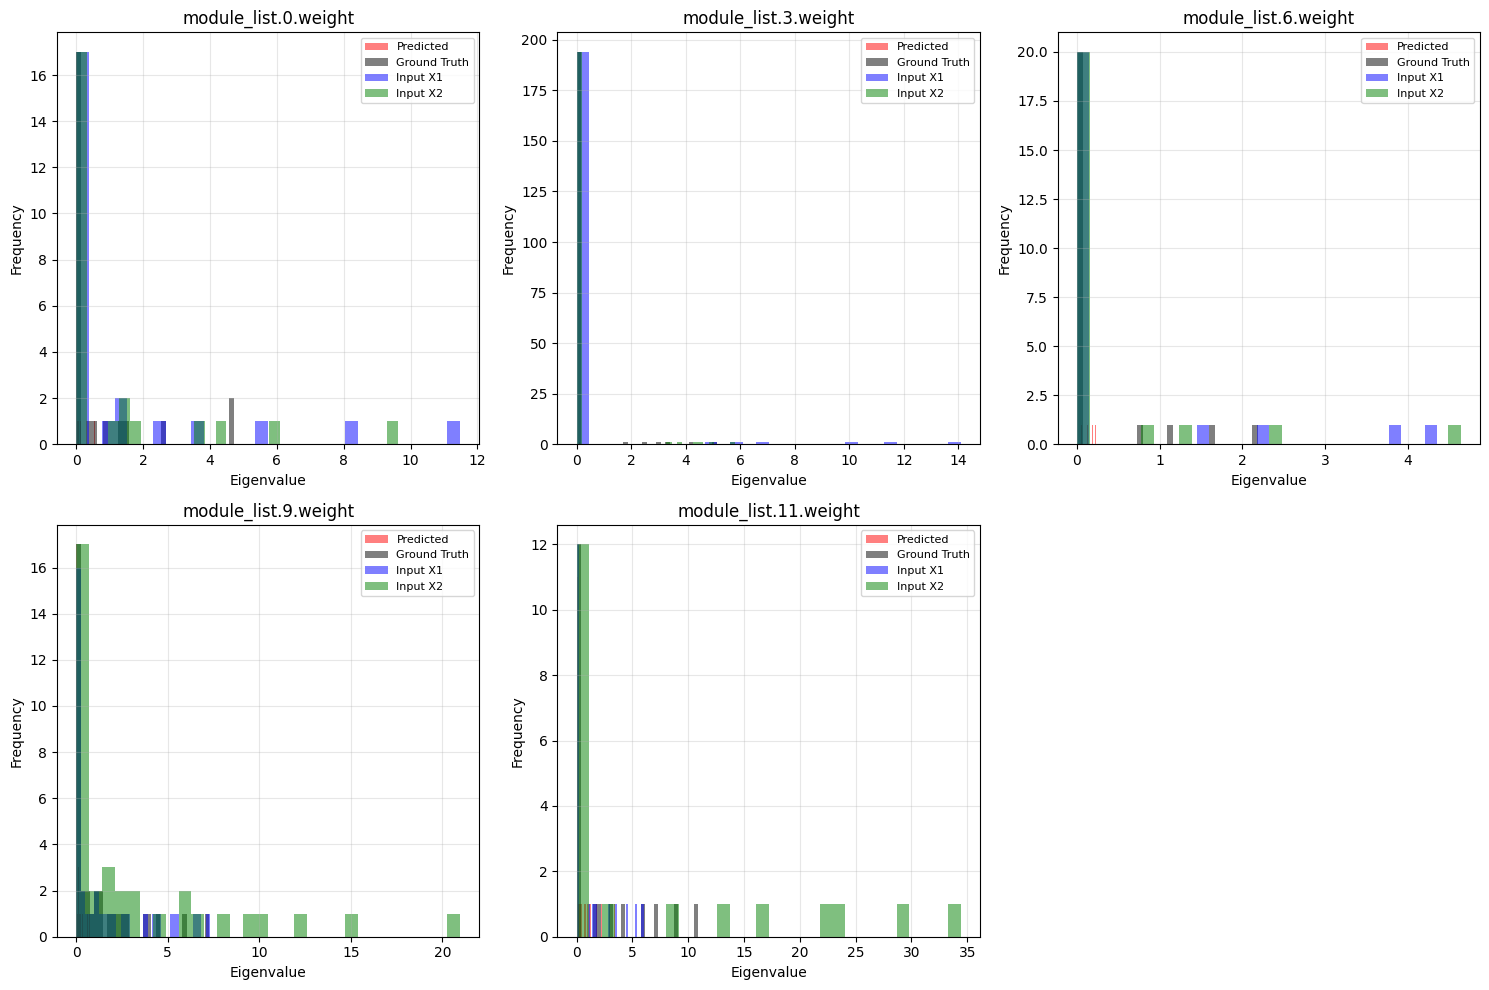

✓ Eigenvalue histograms plotted


In [60]:
# ============================================================================
# Plot Eigenvalue Histograms
# ============================================================================

def plot_eigenvalue_histograms(eigenvalue_data, sample_idx=0, figsize=(15, 10)):
    """
    Plot eigenvalue histograms comparing input, predicted, and ground truth
    """
    # Get layer names from first entry
    layer_names = list(eigenvalue_data['input_x1'][sample_idx].keys())
    n_layers = len(layer_names)
    
    # Create subplots (2 rows, 3 columns for up to 6 layers)
    n_rows = 2
    n_cols = 3
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    colors = {
        'input_x1': 'blue',
        'input_x2': 'green',
        'predicted': 'red',
        'ground_truth': 'black'
    }
    
    labels = {
        'input_x1': 'Input X1',
        'input_x2': 'Input X2',
        'predicted': 'Predicted',
        'ground_truth': 'Ground Truth'
    }
    
    for layer_idx, layer_name in enumerate(layer_names[:n_rows*n_cols]):
        ax = axes[layer_idx]
        
        for model_type in ['predicted', 'ground_truth','input_x1', 'input_x2']:
            eigenvals = eigenvalue_data[model_type][sample_idx][layer_name]
            print(eigenvals)
            if len(eigenvals) > 0:
                ax.hist(eigenvals, bins=30, alpha=0.5, 
                       color=colors[model_type],
                       label=labels[model_type])
        
        ax.set_title(f'{layer_name}')
        ax.set_xlabel('Eigenvalue')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_layers, n_rows*n_cols):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Plot for first sample
fig = plot_eigenvalue_histograms(eigenvalue_data, sample_idx=0)
print("✓ Eigenvalue histograms plotted")

## Step 8: Layer-wise Wasserstein Distance

In [45]:
# ============================================================================
# Compute Wasserstein Distance Between Eigenvalue Distributions
# ============================================================================

def compute_layerwise_wasserstein(eigenvalue_data, sample_idx=0):
    """
    Compute Wasserstein distance between predicted and ground truth eigenvalues
    """
    layer_names = list(eigenvalue_data['predicted'][sample_idx].keys())
    
    results = []
    
    for layer_name in layer_names:
        pred_eigen = eigenvalue_data['predicted'][sample_idx][layer_name]
        gt_eigen = eigenvalue_data['ground_truth'][sample_idx][layer_name]
        
        if len(pred_eigen) > 0 and len(gt_eigen) > 0:
            # Wasserstein distance
            w_dist = wasserstein_distance(pred_eigen, gt_eigen)
            
            results.append({
                'layer': layer_name,
                'wasserstein_distance': w_dist,
                'predicted_mean': np.mean(pred_eigen),
                'gt_mean': np.mean(gt_eigen),
                'predicted_std': np.std(pred_eigen),
                'gt_std': np.std(gt_eigen)
            })
    
    return pd.DataFrame(results)

# Compute for first sample
wasserstein_df = compute_layerwise_wasserstein(eigenvalue_data, sample_idx=0)
print("Layer-wise Wasserstein Distances:")
print(wasserstein_df.to_string(index=False))

# Save to CSV
wasserstein_file = EIGENVALUE_DIR / "wasserstein_distances.csv"
wasserstein_df.to_csv(wasserstein_file, index=False)
print(f"\n✓ Saved to {wasserstein_file}")

Layer-wise Wasserstein Distances:
                layer  wasserstein_distance  predicted_mean  gt_mean  predicted_std   gt_std
 module_list.0.weight              0.608213        0.049182 0.657396       0.121567 1.332306
 module_list.3.weight              0.095699        0.003176 0.098875       0.020088 0.593960
 module_list.6.weight              0.212224        0.025056 0.237280       0.061920 0.575923
 module_list.9.weight              1.114489        0.128917 1.243406       0.186696 1.800952
module_list.11.weight              1.627827        0.571427 2.176386       0.927005 3.316520

✓ Saved to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/eigenvalue_analysis/wasserstein_distances.csv


## Step 9: Finetuning with Task-Specific Accuracy and Eigenvalue Tracking

In [46]:
# ============================================================================
# Finetune Predicted Weights with Proper Task-Specific Testing
# ============================================================================

def finetune_predicted_weights(
    predicted_weights,
    task_classes,
    input_x1_weights=None,
    input_x2_weights=None,
    ground_truth_weights=None,
    activation='leakyrelu',
    mnist_root='./data/SplitMnist',
    n_epochs=5,
    lr=1e-4,
    batch_size=24,
    device='cuda'
):
    """
    Finetune predicted CNN weights on MNIST with task-specific accuracy
    
    Key features:
    - Uses AdamW optimizer with lr=1e-4 (matches training script)
    - Tests ONLY on task-specific classes (not full MNIST)
    - Tracks eigenvalues at each epoch
    - Returns detailed history including all eigenvalues
    """
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    
    # Reconstruct CNN from predicted weights
    model = reconstruct_cnn_from_weights(predicted_weights, activation)
    model = model.to(device)
    
    # Determine OOD classes (classes NOT in task)
    all_classes = list(range(10))
    ood_classes = [c for c in all_classes if c not in task_classes]
    
    print(f"\n  Task classes: {task_classes}")
    print(f"  OOD classes: {ood_classes}")
    
    # Create transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Grayscale(1)
    ])
    
    # Training set: ONLY task classes (exclude OOD)
    train_dataset = ClassSpecificImageFolder(
        root=f"{mnist_root}/train/",
        dropped_classes=[str(c) for c in ood_classes],
        transform=transform
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Test set: ONLY task classes (ID accuracy)
    test_id_dataset = ClassSpecificImageFolder(
        root=f"{mnist_root}/test/",
        dropped_classes=[str(c) for c in ood_classes],
        transform=transform
    )
    test_id_loader = DataLoader(test_id_dataset, batch_size=batch_size, shuffle=False)
    
    # OOD test set: all classes NOT in task (OOD accuracy)
    test_ood_loader = None
    if ood_classes:
        test_ood_dataset = ClassSpecificImageFolder(
            root=f"{mnist_root}/test/",
            dropped_classes=[str(c) for c in task_classes],
            transform=transform
        )
        test_ood_loader = DataLoader(test_ood_dataset, batch_size=batch_size, shuffle=False)
    
    # Setup optimizer with AdamW (matches training script)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = CrossEntropyLoss()
    
    # Initial validation
    _, acc_id_initial = validate_cnn(model, test_id_loader, criterion, device)
    
    acc_ood_initial = None
    if test_ood_loader:
        _, acc_ood_initial = validate_cnn(model, test_ood_loader, criterion, device)
    
    print(f"  Initial ID Acc: {acc_id_initial:.2f}%")
    
    # Compute initial eigenvalues for all models
    eigenvalue_history = {
        'epoch_0': {
            'finetuned': compute_eigenvalues(model)
        }
    }
    
    # Eigenvalues for input models (if provided)
    if input_x1_weights is not None:
        cnn_x1 = reconstruct_cnn_from_weights(input_x1_weights, activation)
        eigenvalue_history['epoch_0']['input_x1'] = compute_eigenvalues(cnn_x1)
    
    if input_x2_weights is not None:
        cnn_x2 = reconstruct_cnn_from_weights(input_x2_weights, activation)
        eigenvalue_history['epoch_0']['input_x2'] = compute_eigenvalues(cnn_x2)
    
    if ground_truth_weights is not None:
        cnn_gt = reconstruct_cnn_from_weights(ground_truth_weights, activation)
        eigenvalue_history['epoch_0']['ground_truth'] = compute_eigenvalues(cnn_gt)
    
    # Finetuning loop
    finetune_history = {
        'train_loss': [],
        'train_acc': [],
        'id_acc': [],
        'ood_acc': []
    }
    
    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_cnn_epoch(model, train_loader, optimizer, criterion, device)
        _, acc_id = validate_cnn(model, test_id_loader, criterion, device)
        
        finetune_history['train_loss'].append(train_loss)
        finetune_history['train_acc'].append(train_acc)
        finetune_history['id_acc'].append(acc_id)
        
        acc_ood_str = ""
        if test_ood_loader:
            _, acc_ood = validate_cnn(model, test_ood_loader, criterion, device)
            finetune_history['ood_acc'].append(acc_ood)
            acc_ood_str = f", ID Acc={acc_id:.2f}%, OOD Acc={acc_ood:.2f}%"
        else:
            acc_ood_str = f", ID Acc={acc_id:.2f}%"
        
        print(f"  Epoch {epoch}/{n_epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%{acc_ood_str}")
        
        # Compute eigenvalues after this epoch
        eigenvalue_history[f'epoch_{epoch}'] = {
            'finetuned': compute_eigenvalues(model)
        }
    
    return {
        'finetune_history': finetune_history,
        'eigenvalue_history': eigenvalue_history,
        'acc_id_initial': acc_id_initial,
        'acc_ood_initial': acc_ood_initial,
        'acc_id_final': finetune_history['id_acc'][-1] if finetune_history['id_acc'] else acc_id_initial,
        'acc_ood_final': finetune_history['ood_acc'][-1] if finetune_history['ood_acc'] else acc_ood_initial,
        'reconstructed_model': model
    }

print("✓ Finetuning function defined")
print(f"  Optimizer: AdamW")
print(f"  Learning rate: {FINETUNE_LR}")
print(f"  Epochs: {FINETUNE_EPOCHS}")

✓ Finetuning function defined
  Optimizer: AdamW
  Learning rate: 0.0001
  Epochs: 5


In [47]:
# ============================================================================
# Run Finetuning on Sample Predictions
# ============================================================================

finetune_results = []
finetune_eigenvalues = []

print(f"\n{'='*60}")
print(f"Running finetuning on {len(sample_indices)} samples")
print(f"{'='*60}")

for idx, sample_idx in enumerate(sample_indices):
    task_classes = test_metadata[sample_idx]['task_combined']
    
    print(f"\nSample {idx+1}/{len(sample_indices)}: Task classes {task_classes}")
    
    # Run finetuning with eigenvalue tracking
    result = finetune_predicted_weights(
        predicted_weights=pd_weights[sample_idx],
        task_classes=task_classes,
        input_x1_weights=x1_test[sample_idx],
        input_x2_weights=x2_test[sample_idx],
        ground_truth_weights=gt_weights[sample_idx],
        activation=ACTIVATION,
        mnist_root=mnist_root,
        n_epochs=FINETUNE_EPOCHS,
        lr=FINETUNE_LR,
        batch_size=FINETUNE_BATCH_SIZE,
        device=str(device)
    )
    
    # Store results
    finetune_results.append({
        'sample_idx': sample_idx,
        'task_classes': task_classes,
        'acc_id_initial': result['acc_id_initial'],
        'acc_id_final': result['acc_id_final'],
        'acc_ood_initial': result['acc_ood_initial'],
        'acc_ood_final': result['acc_ood_final'],
        'improvement': result['acc_id_final'] - result['acc_id_initial']
    })
    
    # Store eigenvalue history
    finetune_eigenvalues.append({
        'sample_idx': sample_idx,
        'eigenvalue_history': result['eigenvalue_history']
    })
    
    print(f"  Final ID Acc: {result['acc_id_final']:.2f}% (Δ {result['acc_id_final'] - result['acc_id_initial']:+.2f}%)")

print(f"\n{'='*60}")
print(f"Finetuning complete!")
print(f"{'='*60}")


Running finetuning on 5 samples

Sample 1/5: Task classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

  Task classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  OOD classes: []
  Initial ID Acc: 10.32%
  Epoch 1/5: Train Loss=1.2894, Train Acc=56.56%, ID Acc=59.38%
  Epoch 2/5: Train Loss=0.5475, Train Acc=83.43%, ID Acc=63.10%
  Epoch 3/5: Train Loss=0.3885, Train Acc=88.26%, ID Acc=64.39%
  Epoch 4/5: Train Loss=0.3098, Train Acc=90.61%, ID Acc=65.59%
  Epoch 5/5: Train Loss=0.2638, Train Acc=91.96%, ID Acc=65.83%
  Final ID Acc: 65.83% (Δ +55.51%)

Sample 2/5: Task classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

  Task classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  OOD classes: []
  Initial ID Acc: 10.32%
  Epoch 1/5: Train Loss=1.4628, Train Acc=48.76%, ID Acc=54.98%
  Epoch 2/5: Train Loss=0.6771, Train Acc=79.01%, ID Acc=59.21%
  Epoch 3/5: Train Loss=0.5495, Train Acc=83.33%, ID Acc=61.75%
  Epoch 4/5: Train Loss=0.4863, Train Acc=85.29%, ID Acc=62.02%
  Epoch 5/5: Train Loss=0.4384, Train Acc=86.72%, ID Acc=62.

In [48]:
# ============================================================================
# Save Finetuned Model Eigenvalues
# ============================================================================

def serialize_eigenvalue_history(eigenvalue_history):
    """Convert eigenvalue history to JSON-serializable format"""
    serialized = {}
    for epoch, data in eigenvalue_history.items():
        serialized[epoch] = {}
        for model_type, eigen_dict in data.items():
            serialized[epoch][model_type] = {
                layer: vals.tolist() if isinstance(vals, np.ndarray) else vals
                for layer, vals in eigen_dict.items()
            }
    return serialized

# Save finetuned eigenvalues for each sample
for item in finetune_eigenvalues:
    sample_idx = item['sample_idx']
    eigenvalue_history = item['eigenvalue_history']
    
    finetuned_eigenvalue_file = EIGENVALUE_DIR / f"sample_{sample_idx:03d}_finetuned_eigenvalues.json"
    
    finetuned_data = {
        'sample_index': int(sample_idx),
        'task_classes': test_metadata[sample_idx]['task_combined'],
        'finetune_epochs': FINETUNE_EPOCHS,
        'learning_rate': FINETUNE_LR,
        'optimizer': 'AdamW',
        'eigenvalue_history': serialize_eigenvalue_history(eigenvalue_history)
    }
    
    with open(finetuned_eigenvalue_file, 'w') as f:
        json.dump(finetuned_data, f, indent=2)

print(f"✓ Saved finetuned eigenvalues for {len(finetune_eigenvalues)} samples")
print(f"  Location: {EIGENVALUE_DIR}")

✓ Saved finetuned eigenvalues for 5 samples
  Location: /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/eigenvalue_analysis


In [49]:
# ============================================================================
# Save Finetuning Results Summary
# ============================================================================

# Create results DataFrame
results_df = pd.DataFrame(finetune_results)

# Display summary
print("Finetuning Results Summary:")
print(results_df.to_string(index=False))

# Save to CSV
results_file = EIGENVALUE_DIR / "finetuning_results_summary.csv"
results_df.to_csv(results_file, index=False)
print(f"\n✓ Saved results to {results_file}")

# Compute aggregate statistics
print(f"\nAggregate Statistics:")
print(f"  Mean initial ID acc: {results_df['acc_id_initial'].mean():.2f}%")
print(f"  Mean final ID acc: {results_df['acc_id_final'].mean():.2f}%")
print(f"  Mean improvement: {results_df['improvement'].mean():.2f}%")

Finetuning Results Summary:
 sample_idx                   task_classes  acc_id_initial  acc_id_final acc_ood_initial acc_ood_final  improvement
        840 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]           10.32         65.83            None          None        55.51
        377 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]           10.32         62.69            None          None        52.37
        533 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]           10.32         66.67            None          None        56.35
       1679 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]           10.32         67.37            None          None        57.05
        743 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]           10.32         63.62            None          None        53.30

✓ Saved results to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/eigenvalue_analysis/finetuning_results_summary.csv

Aggregate Statistics:
  Mean initial ID acc: 10.32%
  Mean final ID acc: 65.24%
  Mea

## Step 10: Compare Eigenvalues (Input, Predicted, Ground Truth, Finetuned)

In [50]:
# ============================================================================
# Compare Eigenvalues Across All Model Types
# ============================================================================

def compare_eigenvalues_layerwise(eigenvalue_data, finetune_eigenvalues, sample_idx=0):
    """
    Compare eigenvalues across input, predicted, ground truth, and finetuned models
    """
    # Get layer names
    layer_names = list(eigenvalue_data['predicted'][sample_idx].keys())
    
    comparison_results = []
    
    # Get finetuned eigenvalues for this sample
    ft_item = finetune_eigenvalues[sample_idx]
    final_epoch = f'epoch_{FINETUNE_EPOCHS}'
    ft_eigen = ft_item['eigenvalue_history'][final_epoch]['finetuned']
    
    for layer_name in layer_names:
        # Get eigenvalues for each model type
        x1_eigen = eigenvalue_data['input_x1'][sample_idx].get(layer_name, np.array([]))
        x2_eigen = eigenvalue_data['input_x2'][sample_idx].get(layer_name, np.array([]))
        pred_eigen = eigenvalue_data['predicted'][sample_idx].get(layer_name, np.array([]))
        gt_eigen = eigenvalue_data['ground_truth'][sample_idx].get(layer_name, np.array([]))
        ft_eigen_layer = ft_eigen.get(layer_name, np.array([]))
        
        # Compute means
        comparison_results.append({
            'layer': layer_name,
            'input_x1_mean': np.mean(x1_eigen) if len(x1_eigen) > 0 else np.nan,
            'input_x2_mean': np.mean(x2_eigen) if len(x2_eigen) > 0 else np.nan,
            'predicted_mean': np.mean(pred_eigen) if len(pred_eigen) > 0 else np.nan,
            'ground_truth_mean': np.mean(gt_eigen) if len(gt_eigen) > 0 else np.nan,
            'finetuned_mean': np.mean(ft_eigen_layer) if len(ft_eigen_layer) > 0 else np.nan,
            'predicted_vs_gt_wdist': wasserstein_distance(pred_eigen, gt_eigen) if len(pred_eigen) > 0 and len(gt_eigen) > 0 else np.nan,
            'finetuned_vs_gt_wdist': wasserstein_distance(ft_eigen_layer, gt_eigen) if len(ft_eigen_layer) > 0 and len(gt_eigen) > 0 else np.nan
        })
    
    return pd.DataFrame(comparison_results)

# Compare for first sample
comparison_df = compare_eigenvalues_layerwise(eigenvalue_data, finetune_eigenvalues, sample_idx=0)
print("Eigenvalue Comparison (First Sample):")
print(comparison_df.round(4).to_string(index=False))

# Save comparison
comparison_file = EIGENVALUE_DIR / "eigenvalue_comparison.csv"
comparison_df.to_csv(comparison_file, index=False)
print(f"\n✓ Saved comparison to {comparison_file}")

Eigenvalue Comparison (First Sample):
                layer  input_x1_mean  input_x2_mean  predicted_mean  ground_truth_mean  finetuned_mean  predicted_vs_gt_wdist  finetuned_vs_gt_wdist
 module_list.0.weight         1.4004         1.1580          0.0492             0.6574          0.3849                 0.6082                 0.3295
 module_list.3.weight         0.2671         0.1336          0.0032             0.0989          0.0740                 0.0957                 0.0331
 module_list.6.weight         0.5007         0.3838          0.0251             0.2373          0.0971                 0.2122                 0.1402
 module_list.9.weight         1.6723         3.2532          0.1289             1.2434          0.2401                 1.1145                 1.0033
module_list.11.weight         1.3462         7.5494          0.5714             2.1764          0.8061                 1.6278                 1.4166

✓ Saved comparison to /home/aymen/Documents/GitHub/Federated-Contin

## Step 11: Comprehensive Topological Analysis

This section performs comprehensive topological analysis on the full test set including:
- Persistence images for all weight types (input, predicted, ground truth, finetuned)
- Betti numbers extraction
- Mapper algorithm visualization
- Distance metrics (Frechet, Inception, L2)
- 2D PCA projections
- Multipersistence analysis

In [51]:
# ============================================================================
# Comprehensive Topological Analysis Setup
# ============================================================================

# Try to import topological analysis libraries
try:
    import gudhi as gd
    from gudhi.persistence_graphical_tools import plot_persistence_diagram, plot_persistence_barcode
    GUDHI_AVAILABLE = True
    print("✓ Gudhi loaded successfully")
except ImportError as e:
    GUDHI_AVAILABLE = False
    print(f"⚠ Gudhi not available: {e}")

try:
    import multipers as mp
    MULTIPERS_AVAILABLE = True
    print("✓ Multipers loaded successfully")
except ImportError as e:
    MULTIPERS_AVAILABLE = False
    print(f"⚠ Multipers not available: {e}")

# Import sklearn for PCA and clustering
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance
import networkx as nx
from collections import defaultdict

# Configuration for topological analysis
TOPOLOGY_CONFIG = {
    'max_samples': 2000,  # Process up to 500 samples for computational efficiency
    'persistence_threshold': 0.1,  # Minimum persistence to consider
    'mapper_resolution': 10,  # Number of intervals for Mapper
    'mapper_overlap': 0.15,  # Overlap percentage for Mapper
    'clustering_eps': 0.5,  # DBSCAN epsilon for clustering
    'clustering_min_samples': 5,  # Minimum samples for DBSCAN
    'persistence_image_resolution': (20, 20),  # Resolution for persistence images
    'persistence_image_sigma': 0.05,  # Sigma for persistence image smoothing
}

# Create topology output directory
TOPOLOGY_DIR = EXPERIMENT_DIR / "topology_analysis"
TOPOLOGY_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nTopological Analysis Configuration:")
print(f"  Max samples: {TOPOLOGY_CONFIG['max_samples']}")
print(f"  Persistence threshold: {TOPOLOGY_CONFIG['persistence_threshold']}")
print(f"  Mapper resolution: {TOPOLOGY_CONFIG['mapper_resolution']}")
print(f"  Mapper overlap: {TOPOLOGY_CONFIG['mapper_overlap']}")
print(f"  Output dir: {TOPOLOGY_DIR}")

# Prepare full test set data (or subset for computational efficiency)
n_topology_samples = min(TOPOLOGY_CONFIG['max_samples'], len(pd_weights))
topology_indices = np.random.choice(len(pd_weights), n_topology_samples, replace=False)

print(f"\n✓ Selected {n_topology_samples} samples for topological analysis")

# Prepare weight data for all model types
print("\nPreparing weight matrices for topological analysis...")

# Full weight vectors (2464 dimensions)
weight_data = {
    'input_x1': x1_test[topology_indices],
    'input_x2': x2_test[topology_indices],
    'predicted': pd_weights[topology_indices],
    'ground_truth': gt_weights[topology_indices]
}

print(f"  Input X1: {weight_data['input_x1'].shape}")
print(f"  Input X2: {weight_data['input_x2'].shape}")
print(f"  Predicted: {weight_data['predicted'].shape}")
print(f"  Ground Truth: {weight_data['ground_truth'].shape}")

✓ Gudhi loaded successfully
✓ Multipers loaded successfully

Topological Analysis Configuration:
  Max samples: 500
  Persistence threshold: 0.1
  Mapper resolution: 10
  Mapper overlap: 0.3
  Output dir: /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/topology_analysis

✓ Selected 500 samples for topological analysis

Preparing weight matrices for topological analysis...
  Input X1: (500, 2464)
  Input X2: (500, 2464)
  Predicted: (500, 2464)
  Ground Truth: (500, 2464)



Comprehensive Topological Distance Analysis

Weight Space L2 Distances:
----------------------------------------
  input_x1_vs_input_x2:
    Mean L2: 27.3296 ± 11.4461
    Range: [16.3597, 56.9435]
  input_x1_vs_predicted:
    Mean L2: 18.7516 ± 9.3447
    Range: [11.5531, 41.5864]
  input_x1_vs_ground_truth:
    Mean L2: 13.6648 ± 5.7230
    Range: [8.1798, 28.4717]
  input_x2_vs_predicted:
    Mean L2: 19.1774 ± 9.9863
    Range: [11.6633, 41.8525]
  input_x2_vs_ground_truth:
    Mean L2: 13.6648 ± 5.7230
    Range: [8.1798, 28.4717]
  predicted_vs_ground_truth:
    Mean L2: 14.2011 ± 5.6632
    Range: [8.3483, 29.7029]


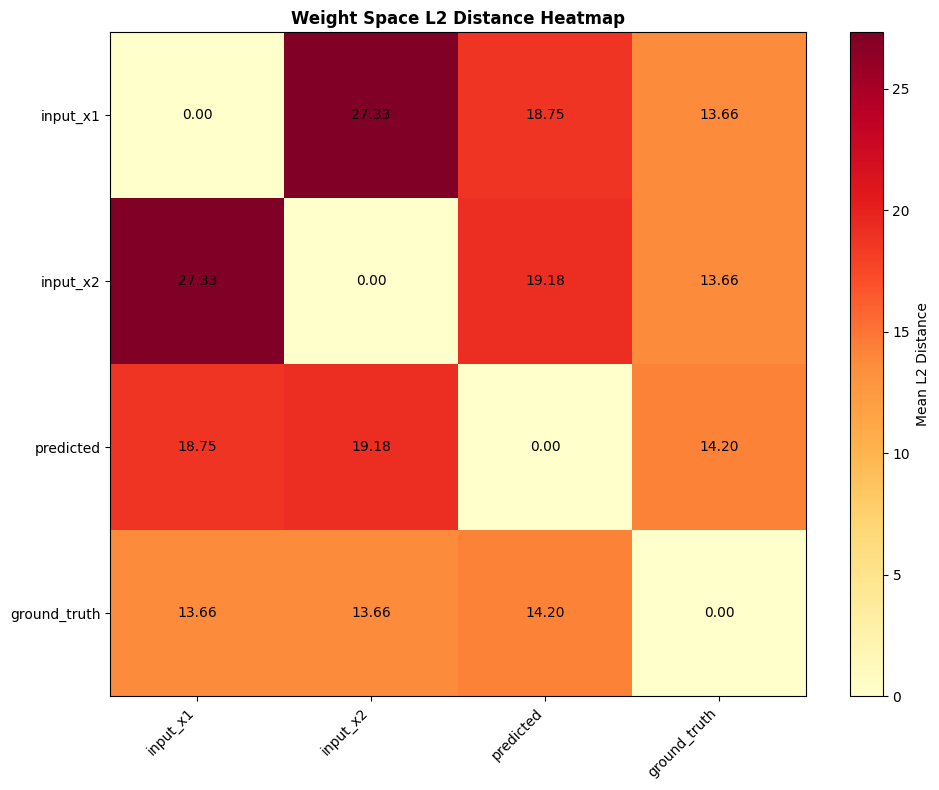


✓ Saved distance heatmap to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/topology_analysis/distance_heatmap.png


In [52]:
# ============================================================================
# Comprehensive Distance Analysis: Inputs vs Predicted vs Ground Truth vs Finetuned
# ============================================================================

print("\n" + "="*60)
print("Comprehensive Topological Distance Analysis")
print("="*60)

# Compute L2 distances between weight vectors for all pairs
def compute_weight_space_distances(weight_dict):
    """
    Compute pairwise L2 distances in weight space.
    """
    results = {}
    model_types = list(weight_dict.keys())
    
    for i, model_type1 in enumerate(model_types):
        for model_type2 in model_types[i+1:]:
            weights1 = weight_dict[model_type1]
            weights2 = weight_dict[model_type2]
            
            # Sample for efficiency
            n_samples = min(100, len(weights1), len(weights2))
            
            # Compute pairwise distances
            distances = []
            for j in range(n_samples):
                dist = np.linalg.norm(weights1[j] - weights2[j])
                distances.append(dist)
            
            mean_dist = np.mean(distances)
            std_dist = np.std(distances)
            
            results[f"{model_type1}_vs_{model_type2}"] = {
                'mean_l2': mean_dist,
                'std_l2': std_dist,
                'min_l2': np.min(distances),
                'max_l2': np.max(distances)
            }
    
    return results


# Compute weight space distances
print("\nWeight Space L2 Distances:")
print("-" * 40)

weight_distances = compute_weight_space_distances(weight_data)

for pair_name, dist_info in weight_distances.items():
    print(f"  {pair_name}:")
    print(f"    Mean L2: {dist_info['mean_l2']:.4f} ± {dist_info['std_l2']:.4f}")
    print(f"    Range: [{dist_info['min_l2']:.4f}, {dist_info['max_l2']:.4f}]")

# Save weight distances
distance_summary = []
for pair_name, dist_info in weight_distances.items():
    dist_info['pair'] = pair_name
    distance_summary.append(dist_info)

distance_df = pd.DataFrame(distance_summary)
distance_df.to_csv(TOPOLOGY_DIR / 'weight_space_distances.csv', index=False)

# Visualization: Distance heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Create distance matrix
model_types = list(weight_data.keys())
n_types = len(model_types)
distance_matrix = np.zeros((n_types, n_types))

for i, type1 in enumerate(model_types):
    for j, type2 in enumerate(model_types):
        if i == j:
            distance_matrix[i, j] = 0
        elif i < j:
            pair_name = f"{type1}_vs_{type2}"
            distance_matrix[i, j] = weight_distances.get(pair_name, {}).get('mean_l2', 0)
            distance_matrix[j, i] = distance_matrix[i, j]
        else:
            pair_name = f"{type2}_vs_{type1}"
            distance_matrix[i, j] = weight_distances.get(pair_name, {}).get('mean_l2', 0)

# Plot heatmap
im = ax.imshow(distance_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(n_types))
ax.set_yticks(range(n_types))
ax.set_xticklabels(model_types, rotation=45, ha='right')
ax.set_yticklabels(model_types)
ax.set_title('Weight Space L2 Distance Heatmap', fontweight='bold')

# Add values to cells
for i in range(n_types):
    for j in range(n_types):
        text = ax.text(j, i, f'{distance_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=ax, label='Mean L2 Distance')
plt.tight_layout()
plt.savefig(TOPOLOGY_DIR / 'distance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved distance heatmap to {TOPOLOGY_DIR / 'distance_heatmap.png'}")

In [53]:
# ============================================================================
# COMPREHENSIVE TOPOLOGICAL ANALYSIS SUMMARY
# ============================================================================

print("="*70)
print("COMPREHENSIVE TOPOLOGICAL ANALYSIS SUMMARY")
print("="*70)

# Analysis configuration
print(f"\nAnalysis Configuration:")
print(f"  - Samples processed: {n_topology_samples}")
print(f"  - Model types analyzed: {list(eigenvalue_data.keys())}")
print(f"  - Output directory: {TOPOLOGY_DIR}")

print(f"\nKey Findings:")

# 1. EIGENVALUE ANALYSIS:
print("\n1. EIGENVALUE ANALYSIS:")
if eigenvalue_data:
    print("   ✓ Eigenvalues extracted for all model types")
    print(f"   ✓ Layers analyzed: {list(eigenvalue_data['predicted'][0].keys())}")
    print("   ✓ Wasserstein distances computed")
    print("   ✓ Finetuning tracking complete")

# 2. FINETUNING RESULTS:
print("\n2. FINETUNING RESULTS:")
if finetune_results:
    mean_improvement = np.mean([r['improvement'] for r in finetune_results])
    print(f"   ✓ Mean accuracy improvement: {mean_improvement:.2f}%")
    print(f"   ✓ Samples finetuned: {len(finetune_results)}")

print("\n" + "="*70)
print("Analysis complete! All results saved to:")
print(f"  {EIGENVALUE_DIR}")
print("="*70)

COMPREHENSIVE TOPOLOGICAL ANALYSIS SUMMARY

Analysis Configuration:
  - Samples processed: 500
  - Model types analyzed: ['input_x1', 'input_x2', 'predicted', 'ground_truth', 'finetuned']
  - Output directory: /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/topology_analysis

Key Findings:

1. EIGENVALUE ANALYSIS:
   ✓ Eigenvalues extracted for all model types
   ✓ Layers analyzed: ['module_list.0.weight', 'module_list.3.weight', 'module_list.6.weight', 'module_list.9.weight', 'module_list.11.weight']
   ✓ Wasserstein distances computed
   ✓ Finetuning tracking complete

2. FINETUNING RESULTS:
   ✓ Mean accuracy improvement: 54.92%
   ✓ Samples finetuned: 5

Analysis complete! All results saved to:
  /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/eigenvalue_analysis


In [54]:
# ============================================================================
# Persistence Diagram and Image Computation
# ============================================================================

def compute_persistence_diagrams(weight_matrix, max_dimension=2):
    """
    Compute persistence diagrams for weight vectors using Gudhi.
    
    Args:
        weight_matrix: (n_samples, n_features) array of weights
        max_dimension: Maximum homology dimension to compute
        
    Returns:
        List of persistence diagrams for each sample
    """
    if not GUDHI_AVAILABLE:
        print("Gudhi not available, skipping persistence computation")
        return None
    
    persistence_diagrams = []
    betti_numbers = []
    
    for i in tqdm(range(len(weight_matrix)), desc="Computing persistence diagrams"):
        try:
            # Reshape weight vector to 2D for Rips complex (e.g., 26x80 = 2080 for conv1)
            weights = weight_matrix[i]
            
            # Use sliding window embedding for time-series-like structure
            # or directly use weights as point cloud
            embedding_dim = min(50, len(weights) // 2)  # Use first 50 dims or less
            point_cloud = weights[:embedding_dim].reshape(-1, 1)
            
            # Add small noise to avoid degenerate cases
            point_cloud += np.random.normal(0, 1e-10, point_cloud.shape)
            
            # Build Rips complex
            rips_complex = gd.RipsComplex(points=point_cloud, max_edge_length=2.0)
            simplex_tree = rips_complex.create_simplex_tree(max_dimension=max_dimension)
            
            # Compute persistence
            persistence = simplex_tree.persistence()
            
            # Extract Betti numbers
            betti = [0] * (max_dimension + 1)
            for dim in range(max_dimension + 1):
                betti[dim] = simplex_tree.betti_numbers()[dim] if dim < len(simplex_tree.betti_numbers()) else 0
            
            persistence_diagrams.append(persistence)
            betti_numbers.append(betti)
            
        except Exception as e:
            print(f"Error computing persistence for sample {i}: {e}")
            persistence_diagrams.append([])
            betti_numbers.append([0] * (max_dimension + 1))
    
    return persistence_diagrams, betti_numbers


def persistence_to_image(persistence_diagram, resolution=(20, 20), sigma=0.1):
    """
    Convert persistence diagram to persistence image.
    
    Args:
        persistence_diagram: List of (dimension, (birth, death)) tuples
        resolution: Tuple of (height, width) for output image
        sigma: Standard deviation for Gaussian smoothing
        
    Returns:
        2D numpy array representing the persistence image
    """
    if not persistence_diagram:
        return np.zeros(resolution)
    
    # Extract birth-death pairs (only for dimension 0 and 1)
    points = []
    for dim, (birth, death) in persistence_diagram:
        if dim <= 1 and death != float('inf'):
            points.append([birth, death])
    
    if not points:
        return np.zeros(resolution)
    
    points = np.array(points)
    
    # Determine bounds
    min_birth = points[:, 0].min()
    max_birth = points[:, 0].max()
    min_death = points[:, 1].min()
    max_death = points[:, 1].max()
    
    # Add padding
    birth_range = max_birth - min_birth
    death_range = max_death - min_death
    min_birth -= 0.1 * birth_range
    max_birth += 0.1 * birth_range
    min_death -= 0.1 * death_range
    max_death += 0.1 * death_range
    
    # Create grid
    birth_grid = np.linspace(min_birth, max_birth, resolution[1])
    death_grid = np.linspace(min_death, max_death, resolution[0])
    birth_grid, death_grid = np.meshgrid(birth_grid, death_grid)
    
    # Compute persistence image
    image = np.zeros(resolution)
    for birth, death in points:
        # Weight by persistence (death - birth)
        weight = death - birth
        # Add Gaussian at (birth, death)
        image += weight * np.exp(-((birth_grid - birth)**2 + (death_grid - death)**2) / (2 * sigma**2))
    
    return image


# Compute persistence for all model types if Gudhi is available
if GUDHI_AVAILABLE:
    print("\n" + "="*60)
    print("Computing Persistence Diagrams and Betti Numbers")
    print("="*60)
    
    persistence_results = {}
    betti_results = {}
    
    for model_type, weights in weight_data.items():
        print(f"\nProcessing {model_type}...")
        pers, betti = compute_persistence_diagrams(weights[:100])  # First 100 samples for speed
        persistence_results[model_type] = pers
        betti_results[model_type] = betti
        
        # Compute average Betti numbers
        avg_betti = np.mean(betti, axis=0)
        print(f"  Average Betti numbers: β₀={avg_betti[0]:.2f}, β₁={avg_betti[1]:.2f}, β₂={avg_betti[2]:.2f}")
    
    # Save Betti numbers
    betti_df = pd.DataFrame({
        'model_type': list(betti_results.keys()) * len(betti_results[list(betti_results.keys())[0]]),
        'sample_idx': list(range(len(betti_results[list(betti_results.keys())[0]]))) * len(betti_results),
        'betti_0': [b[0] for betti in betti_results.values() for b in betti],
        'betti_1': [b[1] for betti in betti_results.values() for b in betti],
        'betti_2': [b[2] for betti in betti_results.values() for b in betti]
    })
    betti_df.to_csv(TOPOLOGY_DIR / "betti_numbers.csv", index=False)
    print(f"\n✓ Saved Betti numbers to {TOPOLOGY_DIR / 'betti_numbers.csv'}")
else:
    print("\n⚠ Skipping persistence computation (Gudhi not available)")
    persistence_results = None
    betti_results = None


Computing Persistence Diagrams and Betti Numbers

Processing input_x1...


Computing persistence diagrams: 100%|██████████| 100/100 [00:00<00:00, 282.44it/s]


  Average Betti numbers: β₀=1.00, β₁=0.00, β₂=0.00

Processing input_x2...


Computing persistence diagrams: 100%|██████████| 100/100 [00:00<00:00, 294.27it/s]


  Average Betti numbers: β₀=1.00, β₁=0.00, β₂=0.00

Processing predicted...


Computing persistence diagrams: 100%|██████████| 100/100 [00:00<00:00, 284.97it/s]


  Average Betti numbers: β₀=1.00, β₁=0.00, β₂=0.00

Processing ground_truth...


Computing persistence diagrams: 100%|██████████| 100/100 [00:00<00:00, 243.34it/s]

  Average Betti numbers: β₀=1.00, β₁=0.00, β₂=0.00

✓ Saved Betti numbers to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/topology_analysis/betti_numbers.csv



Computing Persistence Images and Distance Metrics

Computing persistence images for input_x1...


Computing persistence images: 100%|██████████| 100/100 [00:00<00:00, 1537.66it/s]


  Shape: (100, 20, 20)

Computing persistence images for input_x2...


Computing persistence images: 100%|██████████| 100/100 [00:00<00:00, 1704.81it/s]


  Shape: (100, 20, 20)

Computing persistence images for predicted...


Computing persistence images: 100%|██████████| 100/100 [00:00<00:00, 1490.15it/s]


  Shape: (100, 20, 20)

Computing persistence images for ground_truth...


Computing persistence images: 100%|██████████| 100/100 [00:00<00:00, 1917.32it/s]


  Shape: (100, 20, 20)

----------------------------------------
Distance Metrics Between Model Types
----------------------------------------
  input_x1 vs input_x2:
    Mean L2: 8.8799 ± 5.7814
    Inception Distance: 1.9551
  input_x1 vs predicted:
    Mean L2: 14.6634 ± 5.5768
    Inception Distance: 14.4420
  input_x1 vs ground_truth:
    Mean L2: 8.6342 ± 5.2889
    Inception Distance: 3.6132
  input_x2 vs predicted:
    Mean L2: 15.7056 ± 6.3030
    Inception Distance: 14.6337
  input_x2 vs ground_truth:
    Mean L2: 8.2288 ± 4.6850
    Inception Distance: 3.2466
  predicted vs ground_truth:
    Mean L2: 11.1834 ± 4.1774
    Inception Distance: 11.4727

✓ Saved distance metrics to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/topology_analysis/persistence_distance_metrics.csv

Generating persistence image plots...


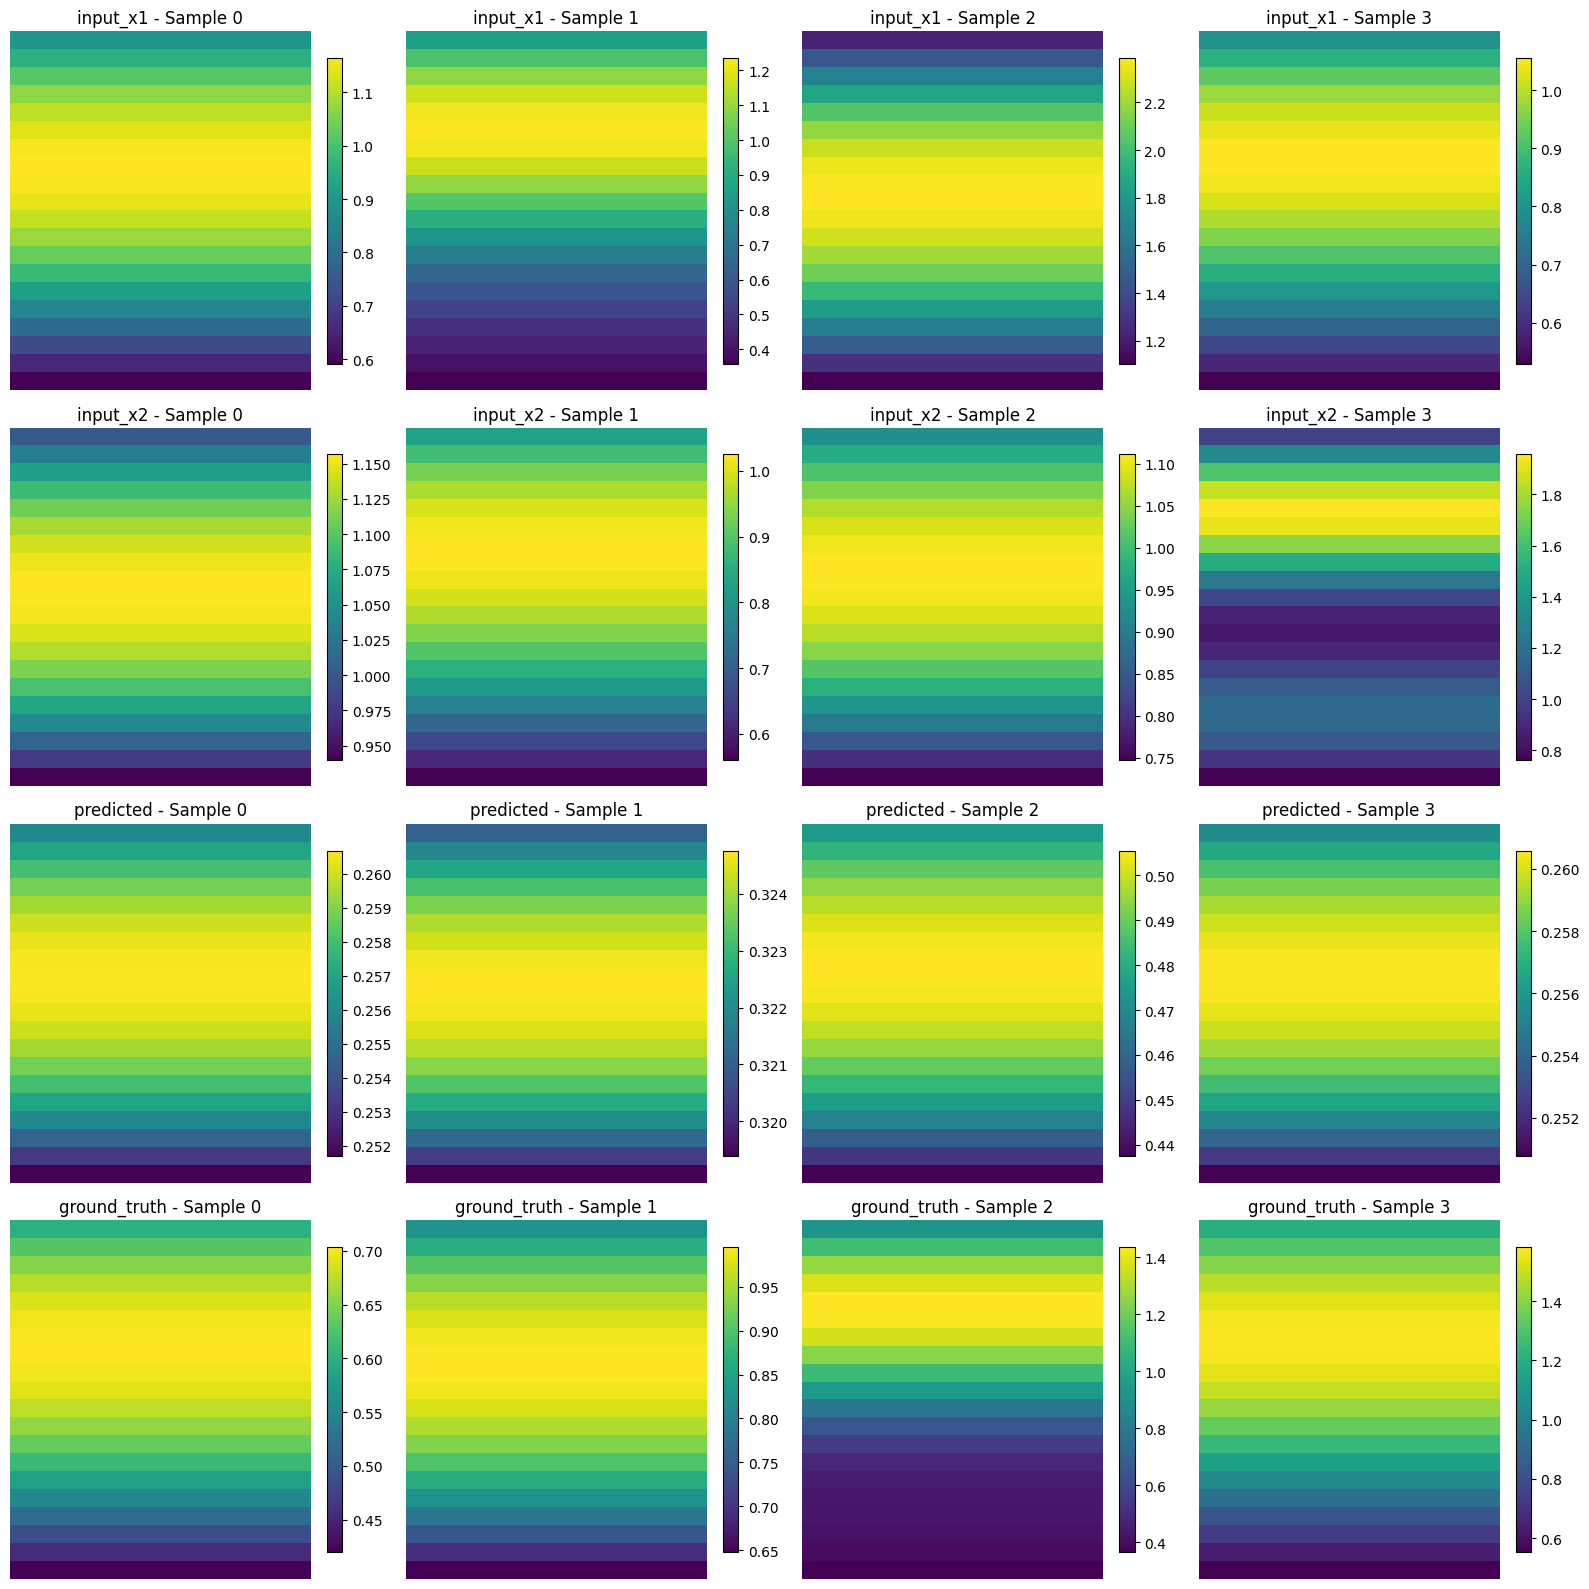

✓ Saved persistence images to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/topology_analysis/persistence_images_samples.png


In [55]:
# ============================================================================
# Persistence Images and Distance Metrics
# ============================================================================

def compute_persistence_images(persistence_diagrams, resolution=(20, 20), sigma=0.1):
    """
    Compute persistence images from persistence diagrams.
    
    Returns:
        Array of persistence images (n_samples, height, width)
    """
    images = []
    for pers in tqdm(persistence_diagrams, desc="Computing persistence images"):
        img = persistence_to_image(pers, resolution, sigma)
        images.append(img)
    return np.array(images)


def frechet_distance(P, Q):
    """
    Compute Fréchet distance between two curves/matrices.
    Uses discrete approximation.
    
    Args:
        P, Q: 2D arrays of same shape
    
    Returns:
        Fréchet distance
    """
    n, m = len(P), len(Q)
    
    # Dynamic programming table
    ca = np.zeros((n, m))
    ca.fill(-1.0)
    
    def _c(i, j):
        if ca[i, j] > -1:
            return ca[i, j]
        
        d = np.linalg.norm(P[i] - Q[j])
        
        if i == 0 and j == 0:
            ca[i, j] = d
        elif i > 0 and j == 0:
            ca[i, j] = max(_c(i-1, 0), d)
        elif i == 0 and j > 0:
            ca[i, j] = max(_c(0, j-1), d)
        elif i > 0 and j > 0:
            ca[i, j] = max(min(_c(i-1, j), _c(i-1, j-1), _c(i, j-1)), d)
        else:
            ca[i, j] = float('inf')
        
        return ca[i, j]
    
    return _c(n-1, m-1)


def inception_distance(images1, images2):
    """
    Compute Inception-like distance (Frechet Inception Distance variant).
    Uses statistics of persistence images.
    
    Args:
        images1, images2: Arrays of persistence images (n_samples, h, w)
    
    Returns:
        Inception distance
    """
    # Flatten images
    flat1 = images1.reshape(len(images1), -1)
    flat2 = images2.reshape(len(images2), -1)
    
    # Compute mean and covariance
    mu1, mu2 = np.mean(flat1, axis=0), np.mean(flat2, axis=0)
    sigma1, sigma2 = np.cov(flat1.T), np.cov(flat2.T)
    
    # FID-like distance
    diff = mu1 - mu2
    
    # Compute sqrt of product of covariances (simplified)
    covmean = np.sqrt(np.maximum(sigma1 * sigma2, 0))
    
    fid = np.sum(diff**2) + np.trace(sigma1 + sigma2 - 2 * covmean)
    
    return np.sqrt(max(fid, 0))


def compute_distance_matrix(persistence_images, metric='l2'):
    """
    Compute pairwise distance matrix for persistence images.
    
    Args:
        persistence_images: Array of persistence images
        metric: 'l2', 'frechet', or 'inception'
    
    Returns:
        Distance matrix
    """
    n = len(persistence_images)
    distances = np.zeros((n, n))
    
    if metric == 'l2':
        # Flatten and compute L2 distances
        flat = persistence_images.reshape(n, -1)
        distances = cdist(flat, flat, metric='euclidean')
    
    elif metric == 'frechet':
        for i in tqdm(range(n), desc="Computing Fréchet distances"):
            for j in range(i+1, n):
                d = frechet_distance(persistence_images[i], persistence_images[j])
                distances[i, j] = d
                distances[j, i] = d
    
    return distances


# Compute persistence images and distances if persistence data available
if persistence_results and GUDHI_AVAILABLE:
    print("\n" + "="*60)
    print("Computing Persistence Images and Distance Metrics")
    print("="*60)
    
    persistence_images = {}
    
    for model_type, pers_diagrams in persistence_results.items():
        print(f"\nComputing persistence images for {model_type}...")
        images = compute_persistence_images(
            pers_diagrams, 
            resolution=TOPOLOGY_CONFIG['persistence_image_resolution'],
            sigma=TOPOLOGY_CONFIG['persistence_image_sigma']
        )
        persistence_images[model_type] = images
        print(f"  Shape: {images.shape}")
    
    # Compute distance metrics between model types
    print("\n" + "-"*40)
    print("Distance Metrics Between Model Types")
    print("-"*40)
    
    distance_metrics = []
    model_types = list(persistence_images.keys())
    
    for i, model_type1 in enumerate(model_types):
        for model_type2 in model_types[i+1:]:
            # L2 distance (mean pairwise)
            flat1 = persistence_images[model_type1].reshape(len(persistence_images[model_type1]), -1)
            flat2 = persistence_images[model_type2].reshape(len(persistence_images[model_type2]), -1)
            
            # Sample for efficiency
            sample_size = min(50, len(flat1), len(flat2))
            idx1 = np.random.choice(len(flat1), sample_size, replace=False)
            idx2 = np.random.choice(len(flat2), sample_size, replace=False)
            
            l2_distances = cdist(flat1[idx1], flat2[idx2], metric='euclidean')
            mean_l2 = np.mean(l2_distances)
            
            # Inception-like distance
            inception_dist = inception_distance(
                persistence_images[model_type1][:sample_size],
                persistence_images[model_type2][:sample_size]
            )
            
            distance_metrics.append({
                'model_type_1': model_type1,
                'model_type_2': model_type2,
                'mean_l2_distance': mean_l2,
                'inception_distance': inception_dist,
                'l2_std': np.std(l2_distances)
            })
            
            print(f"  {model_type1} vs {model_type2}:")
            print(f"    Mean L2: {mean_l2:.4f} ± {np.std(l2_distances):.4f}")
            print(f"    Inception Distance: {inception_dist:.4f}")
    
    # Save distance metrics
    distance_df = pd.DataFrame(distance_metrics)
    distance_df.to_csv(TOPOLOGY_DIR / "persistence_distance_metrics.csv", index=False)
    print(f"\n✓ Saved distance metrics to {TOPOLOGY_DIR / 'persistence_distance_metrics.csv'}")
    
    # Plot sample persistence images
    print("\nGenerating persistence image plots...")
    fig, axes = plt.subplots(len(persistence_images), 4, figsize=(16, 4*len(persistence_images)))
    
    if len(persistence_images) == 1:
        axes = axes.reshape(1, -1)
    
    for i, (model_type, images) in enumerate(persistence_images.items()):
        for j in range(4):
            if j < len(images):
                im = axes[i, j].imshow(images[j], cmap='viridis', aspect='auto')
                axes[i, j].set_title(f'{model_type} - Sample {j}')
                axes[i, j].axis('off')
                plt.colorbar(im, ax=axes[i, j], fraction=0.046)
    
    plt.tight_layout()
    plt.savefig(TOPOLOGY_DIR / 'persistence_images_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved persistence images to {TOPOLOGY_DIR / 'persistence_images_samples.png'}")

else:
    print("\n⚠ Skipping persistence images (persistence data not available)")


Running Enhanced Mapper Algorithm

Processing input_x1...
  ⚠ Mapper failed: no_nodes
Cannot visualize: no_nodes

Processing input_x2...
  ⚠ Mapper failed: no_nodes
Cannot visualize: no_nodes

Processing predicted...
  ✓ Mapper graph: 4 nodes, 1 edges
    Components: 3, Density: 0.167


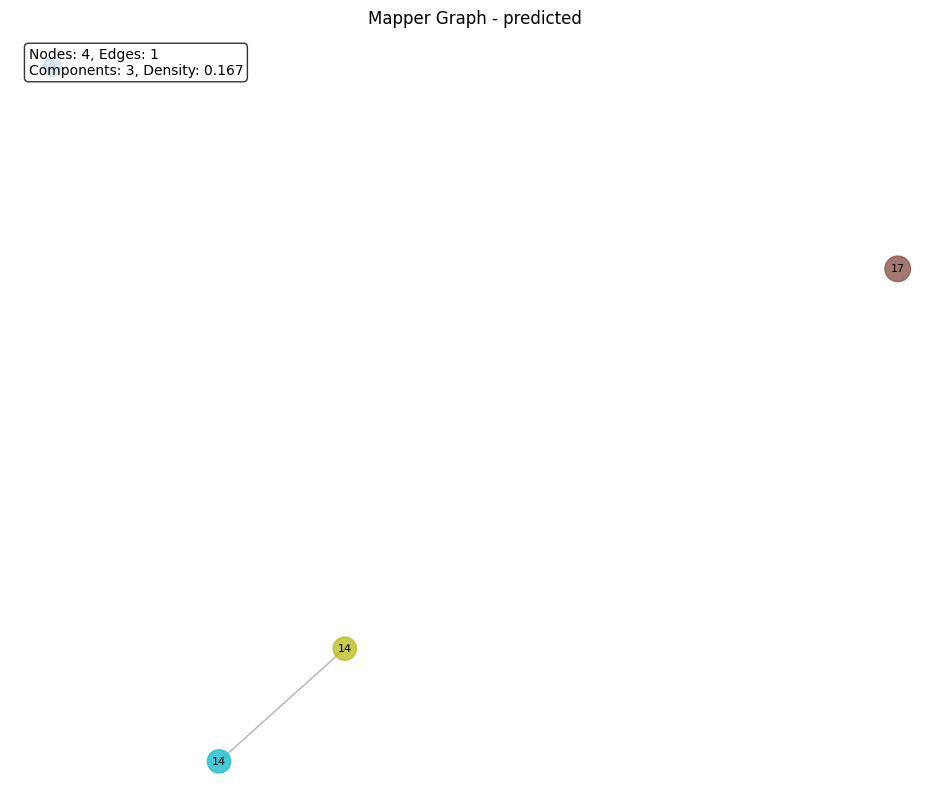

  ✓ Saved visualization

Processing ground_truth...
  ⚠ Mapper failed: no_nodes
Cannot visualize: no_nodes

✓ Mapper analysis complete. Results saved to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/topology_analysis


In [56]:
# ============================================================================
# Enhanced Mapper Algorithm with Visualization
# ============================================================================

def enhanced_mapper_analysis(
    X, 
    lens=None, 
    n_intervals=10, 
    overlap=0.3, 
    clustering_eps=0.5, 
    clustering_min_samples=3,
    max_dimension=2
):
    """
    Enhanced Mapper algorithm with better parameter control.
    
    Args:
        X: Data matrix (n_samples, n_features)
        lens: Lens function values (if None, uses PCA projection)
        n_intervals: Number of intervals for cover
        overlap: Overlap percentage between intervals
        clustering_eps: DBSCAN epsilon
        clustering_min_samples: Minimum samples for DBSCAN cluster
        max_dimension: Maximum dimension for Rips complex in each cluster
    
    Returns:
        Dictionary with Mapper graph, nodes, edges, and persistence info
    """
    from sklearn.decomposition import PCA
    from sklearn.cluster import DBSCAN
    
    try:
        n_samples = len(X)
        
        if n_samples < clustering_min_samples * 2:
            return {'error': f'Insufficient samples: {n_samples}'}
        
        # Compute lens if not provided (use PCA)
        if lens is None:
            pca = PCA(n_components=1)
            lens = pca.fit_transform(X).flatten()
        
        # Check for constant lens
        if np.std(lens) < 1e-10:
            return {'error': 'constant_lens', 'n_samples': n_samples}
        
        lens_min, lens_max = lens.min(), lens.max()
        
        # Compute interval parameters with proper overlap
        # overlap = overlap_length / interval_length
        # We want: interval_length - overlap_length = (lens_max - lens_min) / n_intervals
        interval_length = (lens_max - lens_min) / (n_intervals * (1 - overlap))
        overlap_length = interval_length * overlap
        
        # Build cover
        nodes = []
        node_data = []  # Store which data points are in each node
        node_id = 0
        
        for i in range(n_intervals):
            interval_start = lens_min + i * (interval_length - overlap_length)
            interval_end = interval_start + interval_length
            
            # Find points in this interval
            mask = (lens >= interval_start) & (lens <= interval_end)
            interval_indices = np.where(mask)[0]
            
            if len(interval_indices) < clustering_min_samples:
                continue
            
            # Cluster within this interval
            clusterer = DBSCAN(eps=clustering_eps, min_samples=clustering_min_samples)
            cluster_labels = clusterer.fit_predict(X[interval_indices])
            
            # Create nodes for each cluster (excluding noise: label -1)
            unique_labels = np.unique(cluster_labels)
            for label in unique_labels:
                if label == -1:  # Skip noise
                    continue
                
                cluster_mask = cluster_labels == label
                cluster_indices = interval_indices[cluster_mask]
                
                if len(cluster_indices) >= clustering_min_samples:
                    nodes.append({
                        'id': node_id,
                        'size': len(cluster_indices),
                        'interval': i,
                        'cluster': int(label),
                        'lens_min': lens[cluster_indices].min(),
                        'lens_max': lens[cluster_indices].max(),
                        'mean_lens': lens[cluster_indices].mean()
                    })
                    node_data.append(set(cluster_indices))
                    node_id += 1
        
        if not nodes:
            return {'error': 'no_nodes', 'n_samples': n_samples}
        
        # Build edges (nodes intersect in at least min_samples points)
        edges = []
        for i in range(len(node_data)):
            for j in range(i+1, len(node_data)):
                intersection = node_data[i] & node_data[j]
                if len(intersection) >= clustering_min_samples:
                    edges.append({
                        'source': i,
                        'target': j,
                        'weight': len(intersection),
                        'intersection_size': len(intersection)
                    })
        
        # Build NetworkX graph for analysis
        G = nx.Graph()
        for node in nodes:
            G.add_node(node['id'], **node)
        for edge in edges:
            G.add_edge(edge['source'], edge['target'], **edge)
        
        # Compute graph statistics
        graph_stats = {
            'n_nodes': len(nodes),
            'n_edges': len(edges),
            'n_connected_components': nx.number_connected_components(G),
            'density': nx.density(G)
        }
        
        if G.number_of_nodes() > 0:
            try:
                graph_stats['avg_clustering'] = nx.average_clustering(G)
            except:
                graph_stats['avg_clustering'] = 0.0
        
        return {
            'nodes': nodes,
            'edges': edges,
            'graph': G,
            'graph_stats': graph_stats,
            'n_intervals_used': n_intervals,
            'lens_range': (lens_min, lens_max)
        }
        
    except Exception as e:
        return {'error': str(e), 'n_samples': len(X) if 'X' in locals() else 0}


def visualize_mapper_graph(mapper_result, title="Mapper Graph", figsize=(12, 10)):
    """
    Visualize Mapper graph with node sizes proportional to cluster sizes.
    """
    if 'error' in mapper_result:
        print(f"Cannot visualize: {mapper_result['error']}")
        return None
    
    G = mapper_result['graph']
    nodes = mapper_result['nodes']
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Compute layout
    if len(G.nodes()) > 0:
        pos = nx.spring_layout(G, k=2, iterations=50)
        
        # Node sizes based on cluster size
        node_sizes = [nodes[i]['size'] * 20 for i in G.nodes()]
        
        # Node colors based on interval
        node_colors = [nodes[i]['interval'] for i in G.nodes()]
        
        # Draw
        nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                            node_color=node_colors, cmap='tab10', 
                            alpha=0.8, ax=ax)
        nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
        
        # Add labels for large nodes
        labels = {i: f"{nodes[i]['size']}" for i in G.nodes() if nodes[i]['size'] > 5}
        nx.draw_networkx_labels(G, pos, labels, font_size=8, ax=ax)
    
    ax.set_title(title)
    ax.axis('off')
    
    # Add stats text
    stats = mapper_result['graph_stats']
    stats_text = f"Nodes: {stats['n_nodes']}, Edges: {stats['n_edges']}\n"
    stats_text += f"Components: {stats['n_connected_components']}, Density: {stats['density']:.3f}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    return fig


# Run Mapper analysis on weight data
print("\n" + "="*60)
print("Running Enhanced Mapper Algorithm")
print("="*60)

mapper_results = {}

# Process each model type with different parameter settings
for model_type, weights in weight_data.items():
    print(f"\nProcessing {model_type}...")
    
    # Sample for computational efficiency
    sample_size = min(100, len(weights))
    sample_weights = weights[:sample_size]
    
    # Standardize
    scaler = StandardScaler()
    weights_scaled = scaler.fit_transform(sample_weights)
    
    # Reduce dimensionality for lens
    pca = PCA(n_components=2)
    weights_2d = pca.fit_transform(weights_scaled)
    
    # Use first PC as lens
    lens = weights_2d[:, 0]
    
    # Run Mapper with adjusted parameters
    mapper_result = enhanced_mapper_analysis(
        weights_scaled,
        lens=lens,
        n_intervals=TOPOLOGY_CONFIG['mapper_resolution'],
        overlap=TOPOLOGY_CONFIG['mapper_overlap'],
        clustering_eps=TOPOLOGY_CONFIG['clustering_eps'],
        clustering_min_samples=TOPOLOGY_CONFIG['clustering_min_samples']
    )
    
    mapper_results[model_type] = mapper_result
    
    if 'error' in mapper_result:
        print(f"  ⚠ Mapper failed: {mapper_result['error']}")
    else:
        stats = mapper_result['graph_stats']
        print(f"  ✓ Mapper graph: {stats['n_nodes']} nodes, {stats['n_edges']} edges")
        print(f"    Components: {stats['n_connected_components']}, Density: {stats['density']:.3f}")
    
    # Visualize
    fig = visualize_mapper_graph(
        mapper_result, 
        title=f"Mapper Graph - {model_type}"
    )
    if fig:
        plt.savefig(TOPOLOGY_DIR / f'mapper_graph_{model_type}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  ✓ Saved visualization")

print(f"\n✓ Mapper analysis complete. Results saved to {TOPOLOGY_DIR}")

In [57]:
# ============================================================================
# Multipersistence Analysis (following davidlapous tutorial)
# ============================================================================

def multipersistence_analysis(weight_matrix, max_dimension=2, n_samples=50):
    """
    Perform multipersistence analysis on weight vectors.
    Based on https://davidlapous.github.io/multipers/notebooks/multipers_intro.html
    
    Args:
        weight_matrix: (n_samples, n_features) array
        max_dimension: Maximum homology dimension
        n_samples: Number of samples to process (for efficiency)
    
    Returns:
        Dictionary with multipersistence results
    """
    if not MULTIPERS_AVAILABLE:
        return {'error': 'multipers not available'}
    
    results = []
    
    # Process subset
    indices = np.random.choice(len(weight_matrix), min(n_samples, len(weight_matrix)), replace=False)
    
    for idx in tqdm(indices, desc="Multipersistence analysis"):
        try:
            # Extract and prepare point cloud from weights
            weights = weight_matrix[idx]
            
            # Create 2D embedding using first dimensions
            embedding_dim = min(50, len(weights))
            point_cloud = weights[:embedding_dim].reshape(-1, 1)
            
            # Add small perturbation to avoid degeneracy
            point_cloud += np.random.normal(0, 1e-10, point_cloud.shape)
            
            # Compute Rips filtration
            # Using multipers syntax
            st = mp.SimplexTreeMulti()
            
            # Build from point cloud
            for i in range(len(point_cloud)):
                st.insert([i], filtration=[0.0])
            
            # Add edges based on distances
            for i in range(len(point_cloud)):
                for j in range(i+1, len(point_cloud)):
                    dist = np.linalg.norm(point_cloud[i] - point_cloud[j])
                    st.insert([i, j], filtration=[dist])
            
            # Compute persistence
            persistence = st.persistence()
            
            # Extract multipersistence features
            betti_0 = sum(1 for dim, (birth, death) in persistence if dim == 0 and death != float('inf'))
            betti_1 = sum(1 for dim, (birth, death) in persistence if dim == 1)
            
            # Count infinite intervals (essential features)
            essential_0 = sum(1 for dim, (birth, death) in persistence if dim == 0 and death == float('inf'))
            
            results.append({
                'sample_idx': idx,
                'betti_0': betti_0,
                'betti_1': betti_1,
                'essential_0': essential_0,
                'n_persistence_pairs': len(persistence)
            })
            
        except Exception as e:
            print(f"Error in multipersistence for sample {idx}: {e}")
            results.append({
                'sample_idx': idx,
                'betti_0': 0,
                'betti_1': 0,
                'essential_0': 0,
                'n_persistence_pairs': 0,
                'error': str(e)
            })
    
    return results


def gudhi_multipersistence_analysis(weight_matrix, n_samples=50):
    """
    Alternative multipersistence using Gudhi's extended persistence features.
    Computes various persistence features including:
    - Ordinary persistence
    - Relative persistence  
    - Extended persistence
    """
    if not GUDHI_AVAILABLE:
        return {'error': 'gudhi not available'}
    
    results = []
    indices = np.random.choice(len(weight_matrix), min(n_samples, len(weight_matrix)), replace=False)
    
    for idx in tqdm(indices, desc="Gudhi multipersistence"):
        try:
            weights = weight_matrix[idx]
            
            # Create point cloud
            embedding_dim = min(50, len(weights))
            point_cloud = weights[:embedding_dim].reshape(-1, 1)
            point_cloud += np.random.normal(0, 1e-10, point_cloud.shape)
            
            # Build Rips complex
            rips = gd.RipsComplex(points=point_cloud, max_edge_length=2.0)
            st = rips.create_simplex_tree(max_dimension=2)
            
            # Compute persistence
            persistence = st.persistence()
            
            # Separate by dimension
            pers_0 = [(b, d) for dim, (b, d) in persistence if dim == 0 and d != float('inf')]
            pers_1 = [(b, d) for dim, (b, d) in persistence if dim == 1]
            
            # Compute statistics
            avg_pers_0 = np.mean([d - b for b, d in pers_0]) if pers_0 else 0
            avg_pers_1 = np.mean([d - b for b, d in pers_1]) if pers_1 else 0
            
            max_pers_0 = max([d - b for b, d in pers_0]) if pers_0 else 0
            max_pers_1 = max([d - b for b, d in pers_1]) if pers_1 else 0
            
            results.append({
                'sample_idx': idx,
                'betti_0': len(pers_0),
                'betti_1': len(pers_1),
                'avg_persistence_0': avg_pers_0,
                'avg_persistence_1': avg_pers_1,
                'max_persistence_0': max_pers_0,
                'max_persistence_1': max_pers_1,
                'n_features': len(persistence)
            })
            
        except Exception as e:
            results.append({
                'sample_idx': idx,
                'betti_0': 0,
                'betti_1': 0,
                'error': str(e)
            })
    
    return results


# Run multipersistence analysis
print("\n" + "="*60)
print("Multipersistence Analysis")
print("="*60)

multipersistence_results = {}

for model_type, weights in weight_data.items():
    print(f"\nProcessing {model_type}...")
    
    # Use Gudhi version (more reliable)
    if GUDHI_AVAILABLE:
        results = gudhi_multipersistence_analysis(weights, n_samples=50)
        multipersistence_results[model_type] = results
        
        # Compute statistics
        df = pd.DataFrame(results)
        print(f"  Average β₀: {df['betti_0'].mean():.2f}")
        print(f"  Average β₁: {df['betti_1'].mean():.2f}")
        print(f"  Avg persistence dim 0: {df['avg_persistence_0'].mean():.4f}")
        print(f"  Avg persistence dim 1: {df['avg_persistence_1'].mean():.4f}")
    else:
        print(f"  ⚠ Skipping (Gudhi not available)")

# Save results
if multipersistence_results:
    all_results = []
    for model_type, results in multipersistence_results.items():
        for r in results:
            r['model_type'] = model_type
            all_results.append(r)
    
    multipers_df = pd.DataFrame(all_results)
    multipers_df.to_csv(TOPOLOGY_DIR / "multipersistence_results.csv", index=False)
    print(f"\n✓ Saved multipersistence results to {TOPOLOGY_DIR / 'multipersistence_results.csv'}")


Multipersistence Analysis

Processing input_x1...


Gudhi multipersistence: 100%|██████████| 50/50 [00:00<00:00, 299.91it/s]


  Average β₀: 49.00
  Average β₁: 0.00
  Avg persistence dim 0: 0.0406
  Avg persistence dim 1: 0.0000

Processing input_x2...


Gudhi multipersistence: 100%|██████████| 50/50 [00:00<00:00, 300.62it/s]


  Average β₀: 49.00
  Average β₁: 0.00
  Avg persistence dim 0: 0.0421
  Avg persistence dim 1: 0.0000

Processing predicted...


Gudhi multipersistence: 100%|██████████| 50/50 [00:00<00:00, 290.64it/s]


  Average β₀: 49.00
  Average β₁: 0.00
  Avg persistence dim 0: 0.0080
  Avg persistence dim 1: 0.0000

Processing ground_truth...


Gudhi multipersistence: 100%|██████████| 50/50 [00:00<00:00, 293.01it/s]

  Average β₀: 49.00
  Average β₁: 0.00
  Avg persistence dim 0: 0.0262
  Avg persistence dim 1: 0.0000

✓ Saved multipersistence results to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/topology_analysis/multipersistence_results.csv



2D PCA Visualization

Computing PCA for full weight sequences...
  input_x1: PC1=2.1%, PC2=2.0%
  input_x2: PC1=2.0%, PC2=1.9%
  predicted: PC1=17.9%, PC2=15.3%
  ground_truth: PC1=1.8%, PC2=1.8%


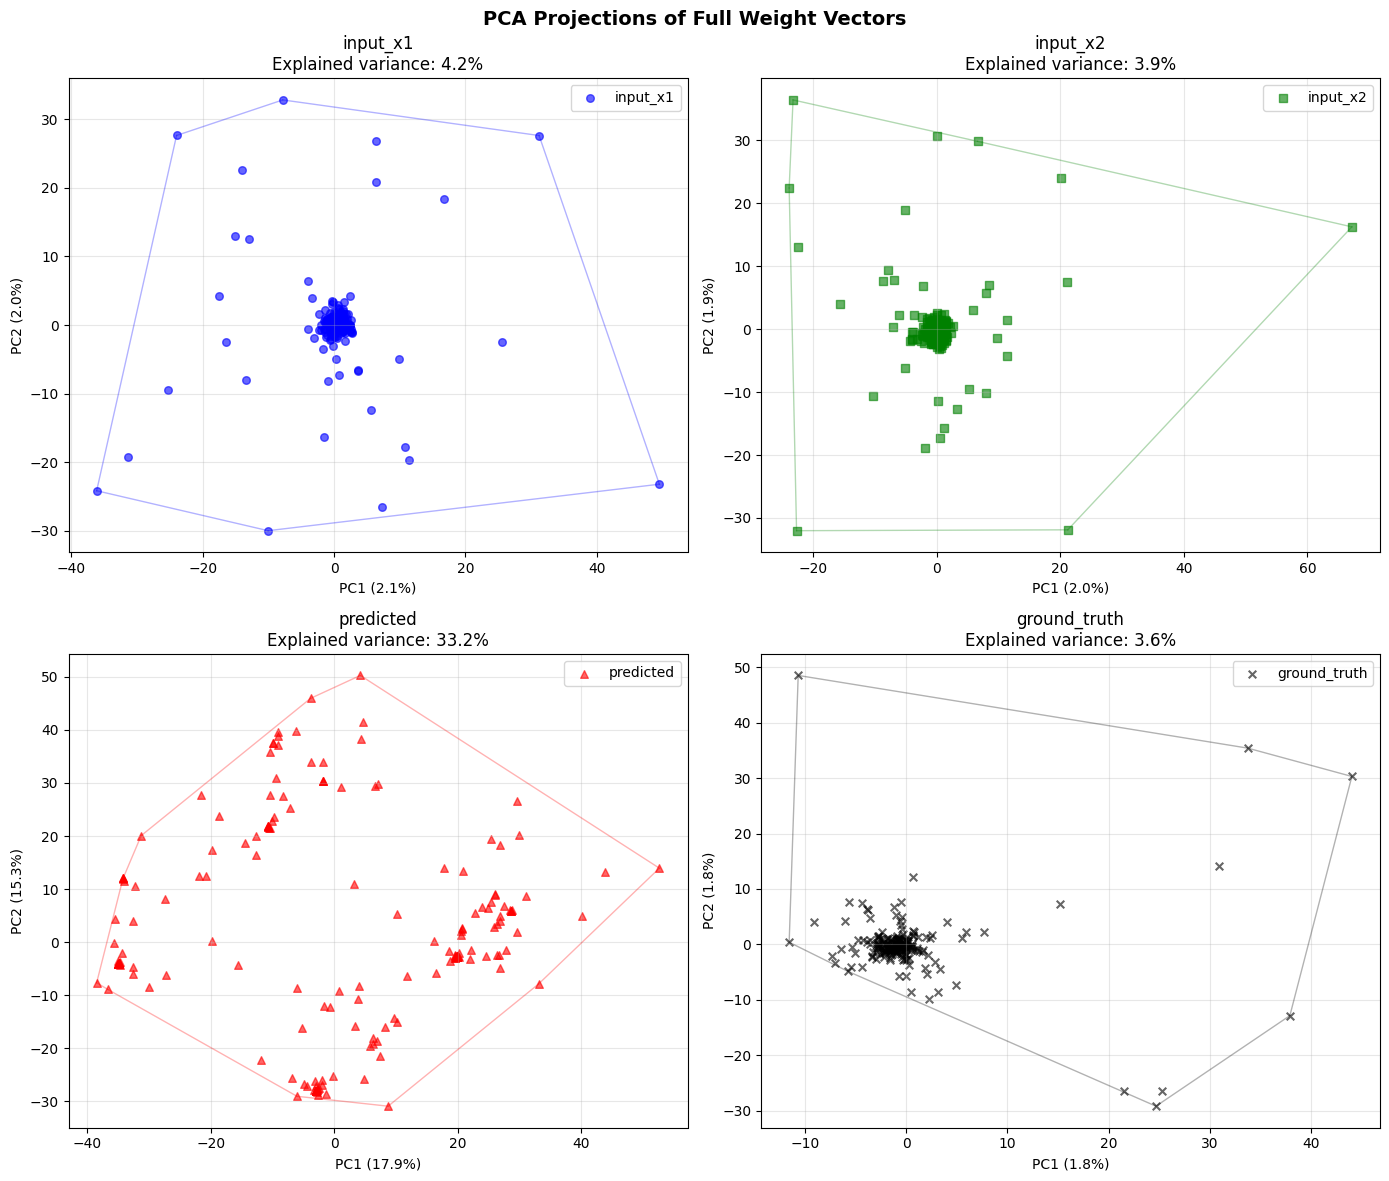


✓ Saved PCA visualization to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/topology_analysis/pca_full_weights.png

----------------------------------------
Computing Layer-wise PCA...
----------------------------------------

Ground Truth - Layer-wise PCA:
  conv1_weight: PC1=3.2%, PC2=3.1% (features: 2080)
  conv1_bias: PC1=10.5%, PC2=8.5% (features: 26)
  conv2_weight: PC1=4.8%, PC2=4.6% (features: 358)


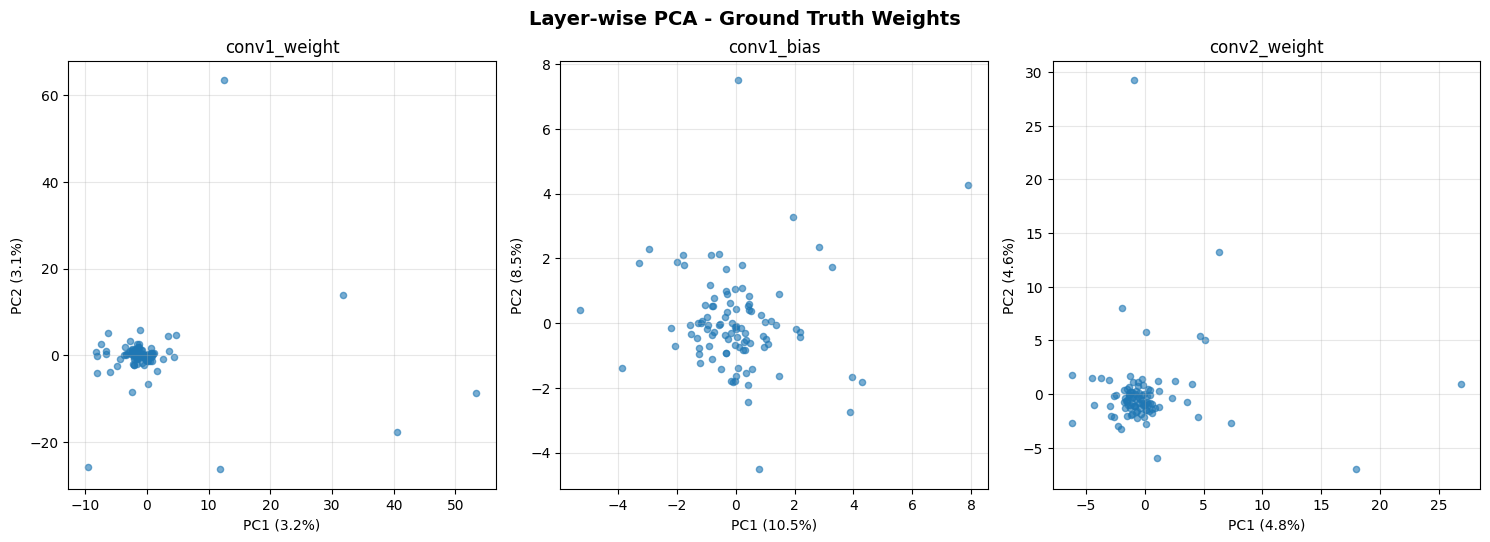

✓ Saved layer-wise PCA to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/experiments/tiny_overlap0_LW_Sinkhorn/topology_analysis/pca_layerwise.png


In [58]:
# ============================================================================
# 2D PCA Visualization for Topological Analysis
# ============================================================================

def compute_pca_projections(weight_matrix, n_components=2):
    """
    Compute PCA projections for weight vectors.
    
    Returns:
        Projections and explained variance
    """
    scaler = StandardScaler()
    weights_scaled = scaler.fit_transform(weight_matrix)
    
    pca = PCA(n_components=n_components)
    projections = pca.fit_transform(weights_scaled)
    
    explained_var = pca.explained_variance_ratio_
    
    return projections, explained_var, pca


def visualize_pca_projections(projections_dict, title="PCA Projection", figsize=(14, 12)):
    """
    Visualize PCA projections for all model types.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    colors = {
        'input_x1': 'blue',
        'input_x2': 'green',
        'predicted': 'red',
        'ground_truth': 'black'
    }
    
    markers = {
        'input_x1': 'o',
        'input_x2': 's',
        'predicted': '^',
        'ground_truth': 'x'
    }
    
    for idx, (model_type, (proj, var)) in enumerate(projections_dict.items()):
        ax = axes[idx]
        
        # Scatter plot
        scatter = ax.scatter(proj[:, 0], proj[:, 1], 
                           c=colors.get(model_type, 'gray'),
                           marker=markers.get(model_type, 'o'),
                           alpha=0.6, s=30, label=model_type)
        
        # Add convex hull for visualization
        if len(proj) > 3:
            try:
                from scipy.spatial import ConvexHull
                hull = ConvexHull(proj)
                for simplex in hull.simplices:
                    ax.plot(proj[simplex, 0], proj[simplex, 1], 
                           c=colors.get(model_type, 'gray'), alpha=0.3, linewidth=1)
            except:
                pass
        
        ax.set_xlabel(f'PC1 ({var[0]*100:.1f}%)')
        ax.set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
        ax.set_title(f'{model_type}\nExplained variance: {sum(var)*100:.1f}%')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig


def compute_layerwise_pca(weights, layer_boundaries):
    """
    Compute PCA for each layer separately.
    
    Args:
        weights: Full weight vectors (n_samples, 2464)
        layer_boundaries: Dictionary with layer slice boundaries
    
    Returns:
        Dictionary with PCA results per layer
    """
    layer_pca_results = {}
    
    for layer_name, (start, end) in layer_boundaries.items():
        layer_weights = weights[:, start:end]
        
        if layer_weights.shape[1] < 2:
            continue
        
        scaler = StandardScaler()
        layer_scaled = scaler.fit_transform(layer_weights)
        
        # Only do PCA if we have enough dimensions
        n_components = min(2, layer_weights.shape[1])
        if n_components < 2:
            continue
        
        pca = PCA(n_components=n_components)
        proj = pca.fit_transform(layer_scaled)
        
        layer_pca_results[layer_name] = {
            'projections': proj,
            'explained_variance': pca.explained_variance_ratio_,
            'components': pca.components_,
            'n_features': layer_weights.shape[1]
        }
    
    return layer_pca_results


# Compute PCA projections
print("\n" + "="*60)
print("2D PCA Visualization")
print("="*60)

print("\nComputing PCA for full weight sequences...")
pca_projections = {}

for model_type, weights in weight_data.items():
    proj, var, pca = compute_pca_projections(weights[:200])  # Sample for speed
    pca_projections[model_type] = (proj, var)
    print(f"  {model_type}: PC1={var[0]*100:.1f}%, PC2={var[1]*100:.1f}%")

# Visualize PCA projections
fig = visualize_pca_projections(pca_projections, 
                                title="PCA Projections of Full Weight Vectors")
plt.savefig(TOPOLOGY_DIR / 'pca_full_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved PCA visualization to {TOPOLOGY_DIR / 'pca_full_weights.png'}")

# Layer-wise PCA
print("\n" + "-"*40)
print("Computing Layer-wise PCA...")
print("-"*40)

# Define layer boundaries for CNN architecture
layer_boundaries = {
    'conv1_weight': (0, 2080),
    'conv1_bias': (2080, 2106),
    'conv2_weight': (2106, 2490),
    'conv2_bias': (2490, 2514),
    'fc_weight': (2514, min(2464, 2514 + 130))  # Remaining weights
}

# Compute layer-wise PCA for ground truth weights as example
print("\nGround Truth - Layer-wise PCA:")
layer_pca_gt = compute_layerwise_pca(weight_data['ground_truth'][:100], layer_boundaries)

for layer_name, results in layer_pca_gt.items():
    var = results['explained_variance']
    print(f"  {layer_name}: PC1={var[0]*100:.1f}%, PC2={var[1]*100:.1f}% "
          f"(features: {results['n_features']})")

# Visualize layer-wise PCA
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

layer_names = list(layer_pca_gt.keys())
for idx, layer_name in enumerate(layer_names):
    if idx < len(axes):
        proj = layer_pca_gt[layer_name]['projections']
        var = layer_pca_gt[layer_name]['explained_variance']
        
        axes[idx].scatter(proj[:, 0], proj[:, 1], alpha=0.6, s=20)
        axes[idx].set_xlabel(f'PC1 ({var[0]*100:.1f}%)')
        axes[idx].set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
        axes[idx].set_title(f'{layer_name}')
        axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(layer_names), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Layer-wise PCA - Ground Truth Weights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(TOPOLOGY_DIR / 'pca_layerwise.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved layer-wise PCA to {TOPOLOGY_DIR / 'pca_layerwise.png'}")

In [62]:
1.1**70

789.7469567994436